# Panel recovery presentation: twenty pMHC-TCR structures, T=0.1

Native-peptide recovery matrices for the panel: mean recovery vs. the crystal's own native peptide,
per-position recovery pooled across crystals, model agreement at specific sites, and whether models
agree on which crystals are diverse.

1. Mean recovery vs. native peptide -- pMHC+TCR
2. Per-position recovery, pooled across crystals (violin)
3. Correlation between models at specific sites
4. Diversity model agreement
5. Mean recovery vs. native peptide -- pMHC only
6. TCR-context benefit, per crystal per model (delta heatmap)
7. Recovery vs. peptide length
8. 9-mers only: per-position contacts vs. recovery, one panel per residue

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from scipy.stats import bootstrap as scipy_bootstrap
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon, mannwhitneyu

ROOT = Path("/home/ubuntu/if-mhc")
FIG_DIR = ROOT / "figures/fig_panel3_recovery_presentation"
FIG_DIR.mkdir(exist_ok=True, parents=True)
MODELS = ["vanilla", "noMHC", "ESM-IF1", "LigandMPNN"]
# Every (structure, arm, model) cell is truncated to the same number of designs. The raw
# counts differ slightly by generator (9,984 / 10,000 / 10,016), and unique-design counts
# scale with sample size, so comparisons across cells need a common N. 9,984 is the largest
# N every cell can supply; designs are i.i.d. draws, so a prefix is a valid subsample.
N_DESIGNS = 9984
MODEL_LABEL = {"vanilla": "ProteinMPNN", "noMHC": "ProteinMPNN (no MHC)", "ESM-IF1": "ESM-IF1",
               "LigandMPNN": "LigandMPNN"}
MODEL_COLOR = {"vanilla": "#0072B2", "noMHC": "#E69F00", "ESM-IF1": "#009E73", "LigandMPNN": "#CC79A7"}
CONDITIONS = ["full", "mhconly"]
COND_LABEL = {"full": "pMHC+TCR", "mhconly": "pMHC only"}
STRUCTS = ["2P5W", "1QSF", "1QRN", "2BNR", "2GJ6", "2F53", "2F54", "3QDG", "3QEQ", "3QFJ", "3GSN",
           "1OGA", "3UTS", "5C0A", "5C0B", "5HHO", "5EU6", "2VLR", "4MJI", "5NME",
           "1BD2", "1LP9", "1MI5", "1QSE", "2AK4", "2BNQ", "2E7L", "2J8U", "2JCC", "2OI9",
           "2PYE", "2UWE", "3C60", "3D3V", "3H9S", "3PWP", "3QDJ", "3QIB", "4FTV", "4JFD",
           "4JFE", "4JFF", "4L3E", "4MNQ", "4OZG", "4P23", "4P5T", "5E9D", "6AM5", "6AMU"]

dataset = pd.read_csv(ROOT / "inputs/pmhc_tcr_dataset/dataset.csv")
dataset = dataset[dataset.pdb.isin(STRUCTS)].set_index("pdb").loc[STRUCTS].reset_index()
natives = dict(zip(dataset["pdb"], dataset["peptide"]))
print(f"{len(dataset)} structures loaded")

50 structures loaded


In [2]:
def peptide_from_ligandmpnn_line(line):
    return line.strip().split(":")[2]

def load_designs(pdb, cond):
    rows = []
    for weights, fname in [("vanilla", f"vanilla_{pdb}.fa"), ("noMHC", f"nomhc_{pdb}.fa")]:
        path = ROOT / f"outputs/panel/{pdb}/{cond}/mpnn/seqs/{fname}"
        lines = path.read_text().splitlines() if path.exists() else []
        lines = lines[:2 * N_DESIGNS + 0]   # uniform sample size across every cell
        for i in range(0, len(lines) - 1, 2):
            if lines[i].startswith(">"):
                rows.append({"peptide": lines[i + 1].strip(), "model": weights})
    path = ROOT / f"outputs/panel/{pdb}/{cond}/esmif/seqs/{pdb}.fa"
    lines = path.read_text().splitlines() if path.exists() else []
    lines = lines[:2 * N_DESIGNS + 0]   # uniform sample size across every cell
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            rows.append({"peptide": lines[i + 1].strip(), "model": "ESM-IF1"})
    path = ROOT / f"outputs/panel/{pdb}/{cond}/ligandmpnn/seqs/{pdb}.fa"
    lines = path.read_text().splitlines() if path.exists() else []
    lines = lines[:2 * N_DESIGNS + 0]   # uniform sample size across every cell
    for i in range(0, len(lines) - 1, 2):
        if lines[i].startswith(">"):
            rows.append({"peptide": peptide_from_ligandmpnn_line(lines[i + 1]), "model": "LigandMPNN"})
    return pd.DataFrame(rows)

def per_position_recovery(pdb, cond, native, length):
    df = load_designs(pdb, cond)
    mat = np.full((length, len(MODELS)), np.nan)
    for j, model in enumerate(MODELS):
        peps = [p for p in df.loc[df.model == model, "peptide"] if len(p) == length]
        if not peps:
            continue
        hits = np.zeros(length)
        for p in peps:
            for pos in range(length):
                if p[pos] == native[pos]:
                    hits[pos] += 1
        mat[:, j] = hits / len(peps)
    return mat

designs = {}
recovery_mat = {}
for pdb in STRUCTS:
    native = natives[pdb]
    length = len(native)
    for cond in CONDITIONS:
        designs[(pdb, cond)] = load_designs(pdb, cond)
        recovery_mat[(pdb, cond)] = per_position_recovery(pdb, cond, native, length)
print("all designs loaded, per-position recovery computed")

all designs loaded, per-position recovery computed


## 1. Mean recovery vs. native peptide -- pMHC+TCR

One cell per (structure, model): mean recovery of the native peptide, pooled across all positions,
pMHC+TCR context only.

Friedman test across models (paired by structure, n=45): chi2=13.13, p=0.004 -- models differ


/tmp/ipykernel_98734/2242520687.py:4: RuntimeWarning: Mean of empty slice
  mat[:, j] = np.nanmean(recovery_mat[(pdb, cond)], axis=0)


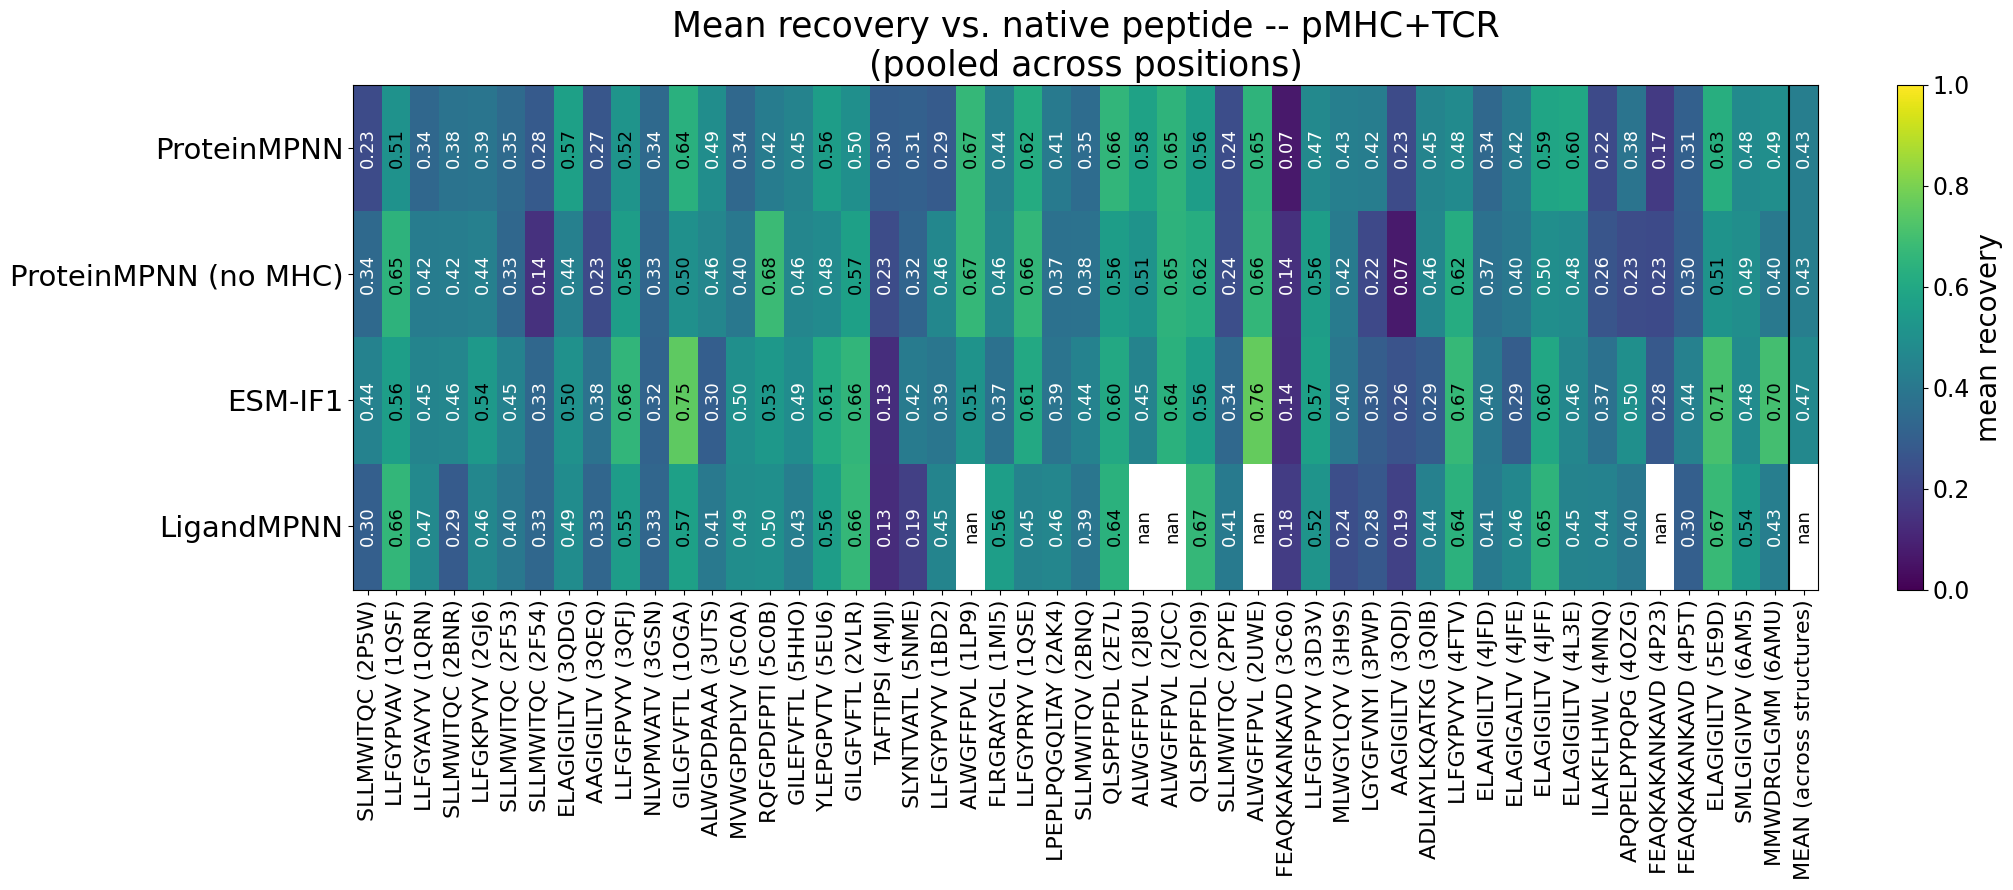

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_mean_recovery_full.png


In [3]:
def mean_recovery_matrix(cond):
    mat = np.zeros((len(MODELS), len(STRUCTS)))
    for j, pdb in enumerate(STRUCTS):
        mat[:, j] = np.nanmean(recovery_mat[(pdb, cond)], axis=0)
    return mat

def plot_mean_recovery_heatmap(mat, title, out_name, cmap="viridis", vmin=0, vmax=1, fmt="{:.2f}",
                               center_white=None, pdb_order=None, add_mean_col=False):
    if pdb_order is None:
        pdb_order = STRUCTS
    col_idx = [STRUCTS.index(pdb) for pdb in pdb_order]
    mat = mat[:, col_idx]
    col_labels = [f"{natives[pdb]}\n({pdb})" for pdb in pdb_order]
    if add_mean_col:
        mean_col = mat.mean(axis=1, keepdims=True)
        mat = np.hstack([mat, mean_col])
        col_labels = col_labels + ["MEAN\n(across\nstructures)"]
    n_cols = len(col_labels)
    # width scales with the number of columns; the old fixed ~11in was sized for 20
    # structures and crushed the labels once the panel grew
    fig, ax = plt.subplots(figsize=(max(11, 0.33 * n_cols + 3.5), 9.0))
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels([MODEL_LABEL[m] for m in MODELS], fontsize=21)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels([l.replace("\n", " ") for l in col_labels], rotation=90,
                       ha="center", fontsize=21 if n_cols <= 25 else 16)
    if add_mean_col:
        ax.axvline(n_cols - 1.5, color="black", linewidth=1.5)
    for i in range(len(MODELS)):
        for j in range(n_cols):
            v = mat[i, j]
            if center_white is None:
                color = "white" if v < (vmin + vmax) / 2 else "black"
            else:
                color = "black" if abs(v) < center_white else "white"
            ax.text(j, i, fmt.format(v), ha="center", va="center", color=color,
                    fontsize=17 if n_cols <= 25 else 13, rotation=90 if n_cols > 25 else 0)
    if title:
        ax.set_title(title, fontsize=25)
    cb = fig.colorbar(im, ax=ax, fraction=0.025, label="mean recovery")
    cb.set_label("mean recovery", fontsize=20)
    cb.ax.tick_params(labelsize=17)
    if add_mean_col:
        # the test is paired across models, so a structure missing any model is dropped whole
        block = np.array([mat[i, :-1] for i in range(len(MODELS))])
        block = block[:, np.isfinite(block).all(axis=0)]
        chi2, p = friedmanchisquare(*[block[i] for i in range(len(MODELS))])
        print(f"Friedman test across models (paired by structure, n={block.shape[1]}): "
              f"chi2={chi2:.2f}, p={p:.3f}"
              + (" -- models differ" if p < 0.05 else " -- no evidence models differ"))
    fig.tight_layout()
    out = FIG_DIR / out_name
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

mat_full = mean_recovery_matrix("full")
plot_mean_recovery_heatmap(mat_full, "Mean recovery vs. native peptide -- pMHC+TCR\n"
                           "(pooled across positions)", "fig_panel3_mean_recovery_full.png",
                           add_mean_col=True)

## 2. Per-position recovery, split by peptide length (violin)

Positions are only comparable within a peptide length. Pooling an 9-mer's P9 with a 13-mer's P9 puts
a C-terminal anchor in the same column as an interior residue, so every panel in this section is one
length group, and each title carries the number of structures it is built from.

Per-crystal points overlaid (jittered, colored by crystal), same convention as fig_iedb2. The violin's
min/max whisker line is intentionally turned off (`showextrema=False`) -- with data this bimodal, the
raw min and max are almost always exactly 0 and 1 at every position, so a whisker spanning the full
axis would just restate the bimodality as if it were uncertainty on the mean, which it is not. The
violin body's actual shape (plus the individual points) already carries the real distributional
information; only a mean marker is kept.

peptide-length groups: 8-mer n=1,  9-mer n=32,  10-mer n=11,  12-mer n=1,  13-mer n=5


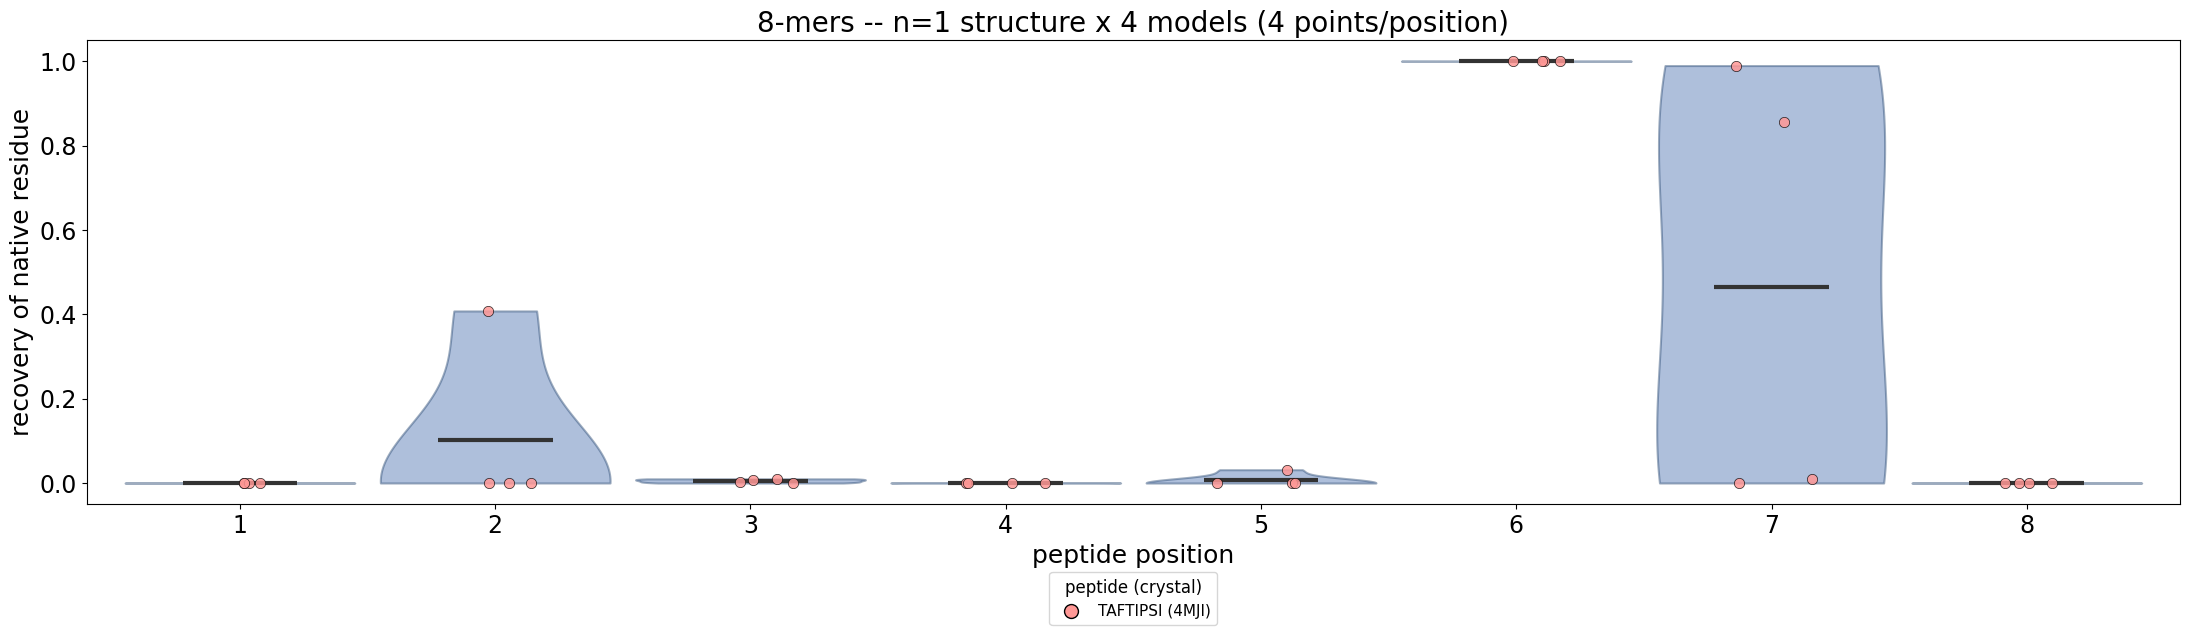

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_full_8mer.png


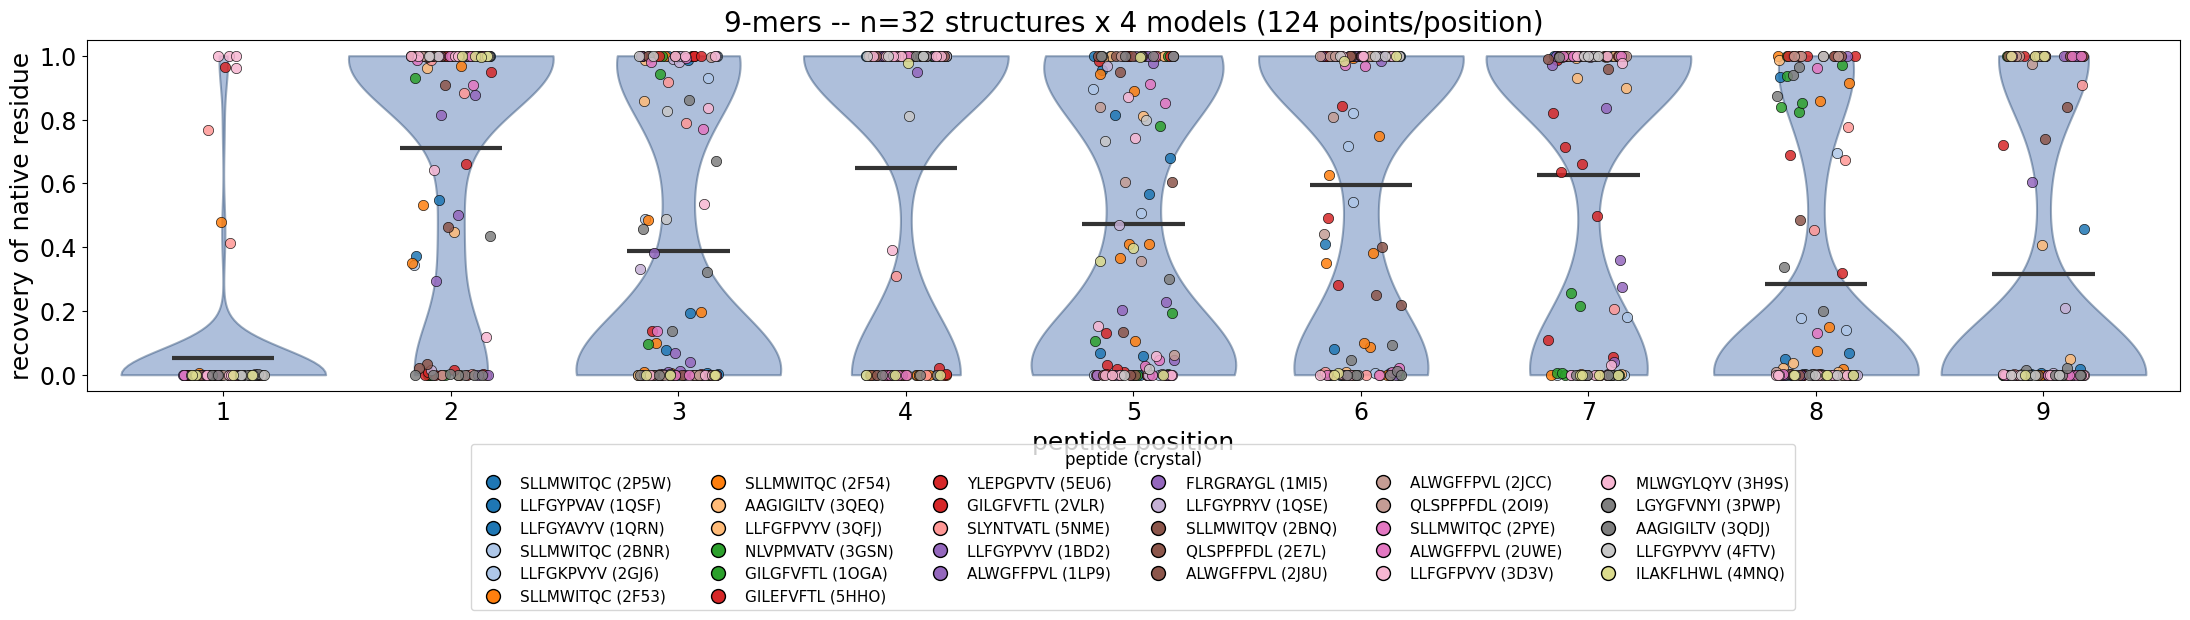

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_full_9mer.png


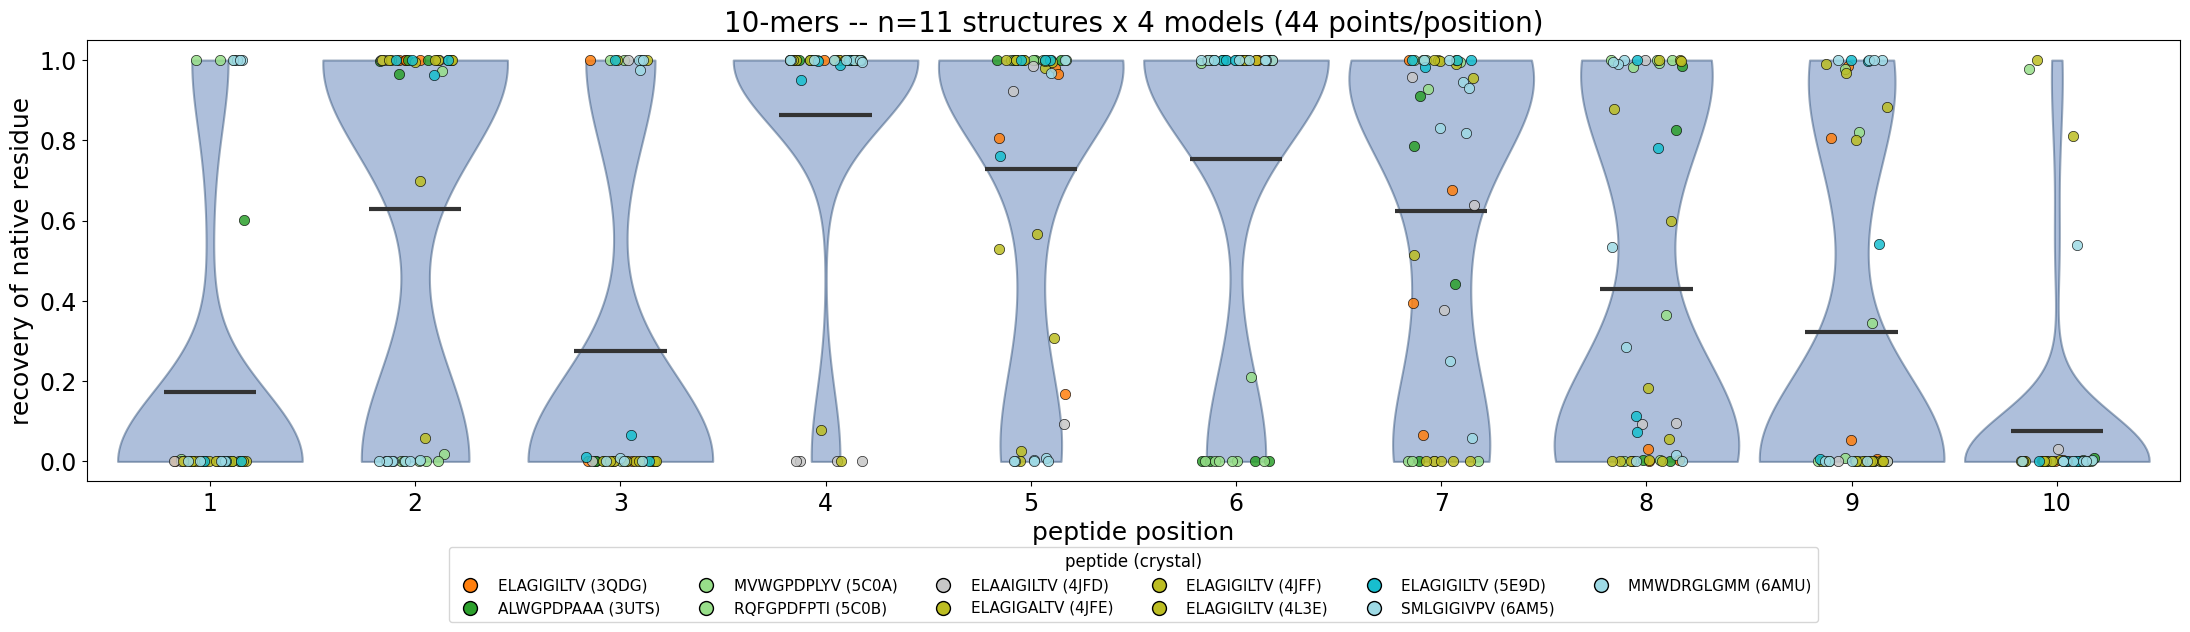

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_full_10mer.png


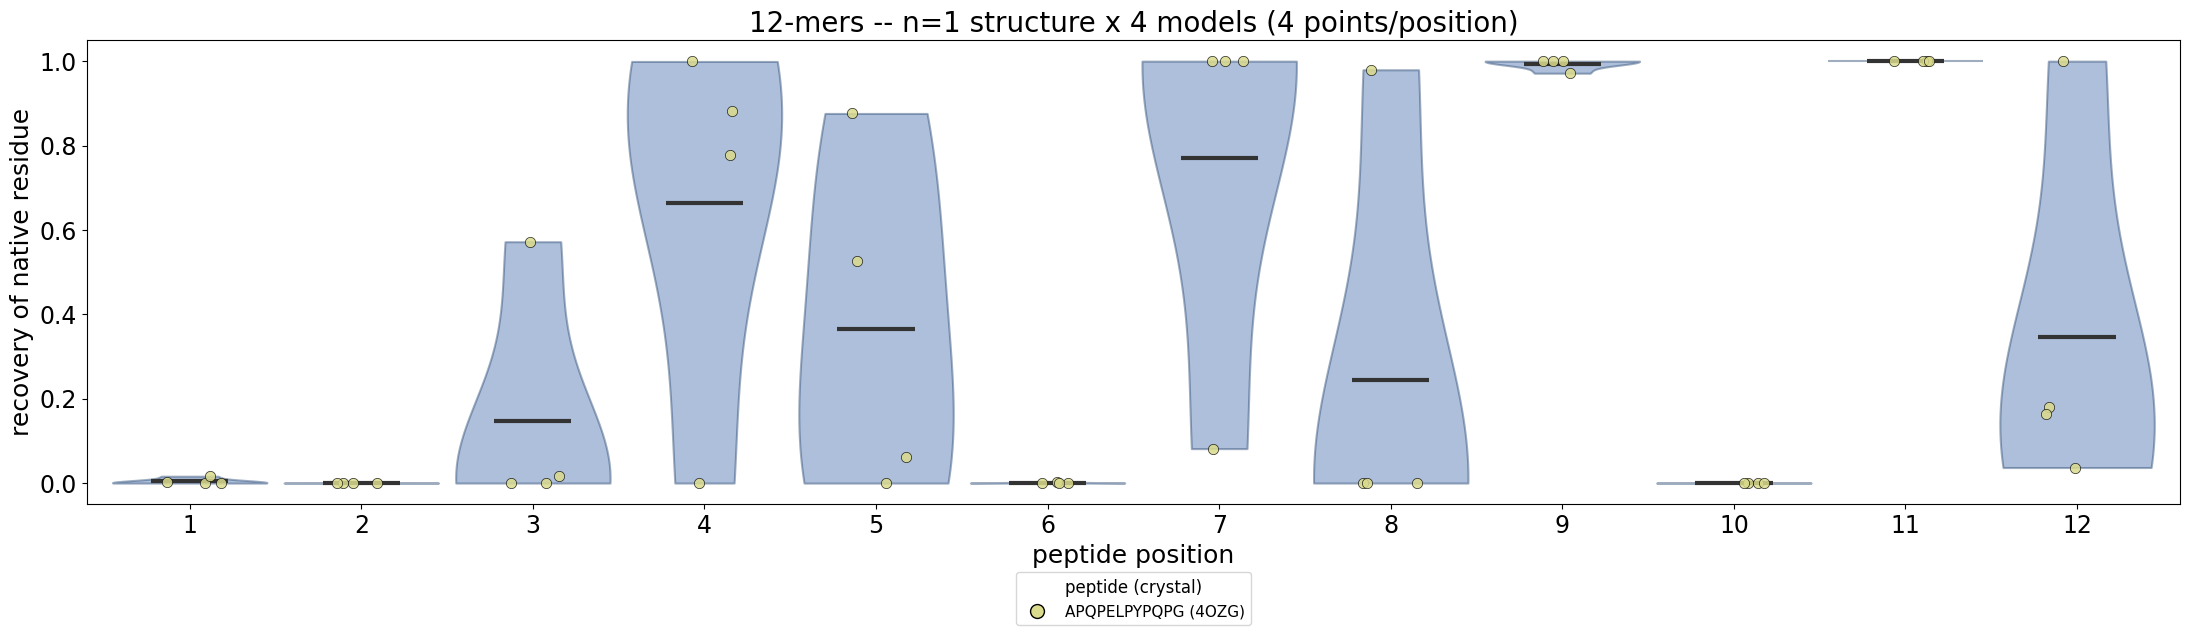

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_full_12mer.png


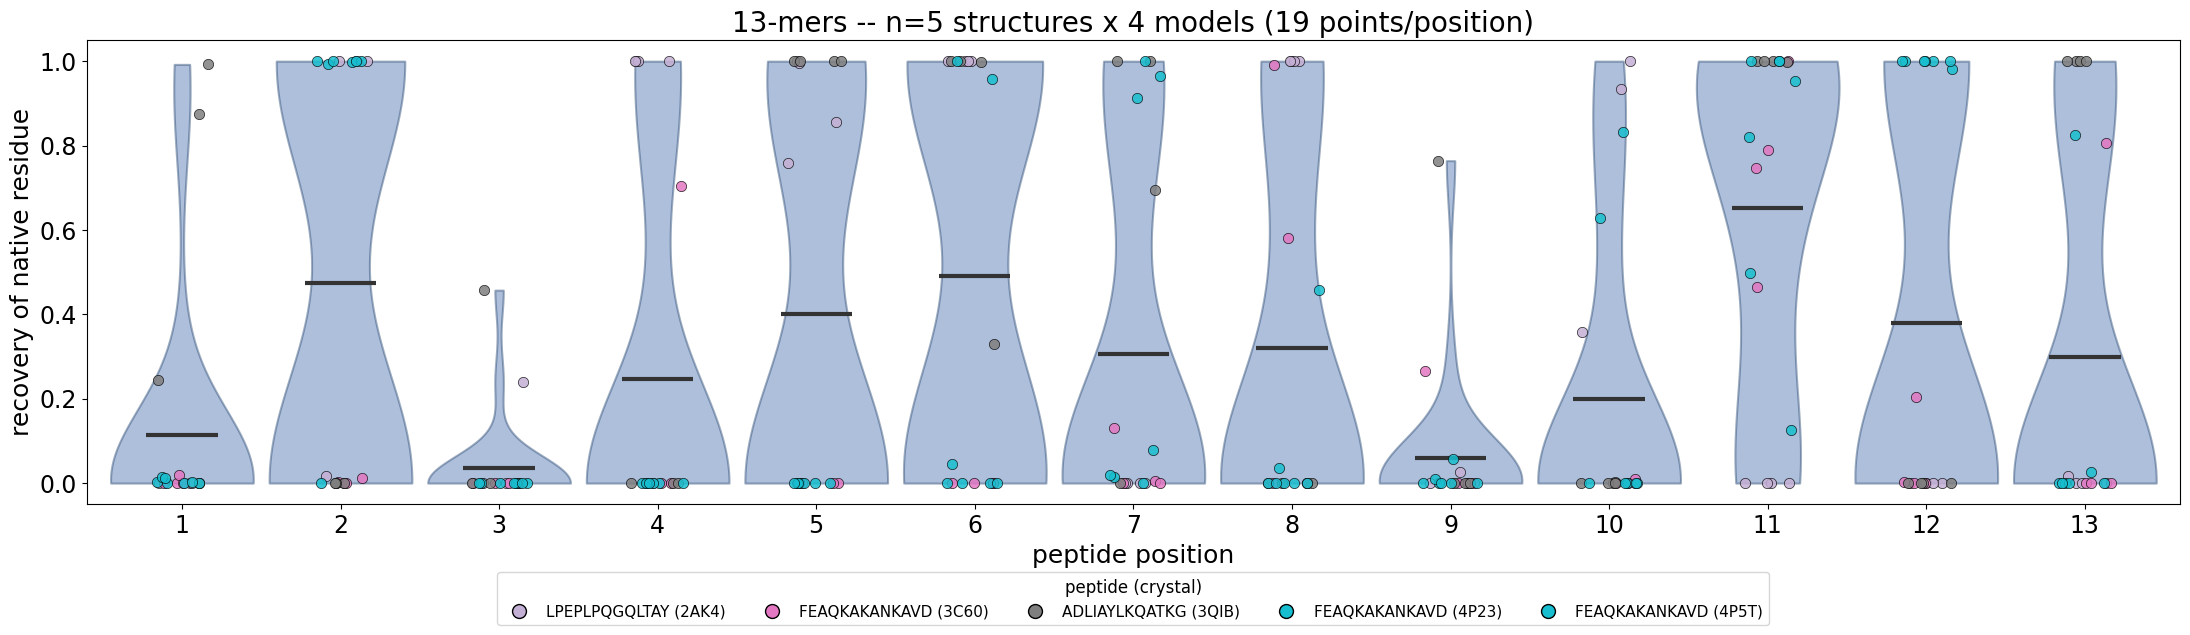

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_full_13mer.png


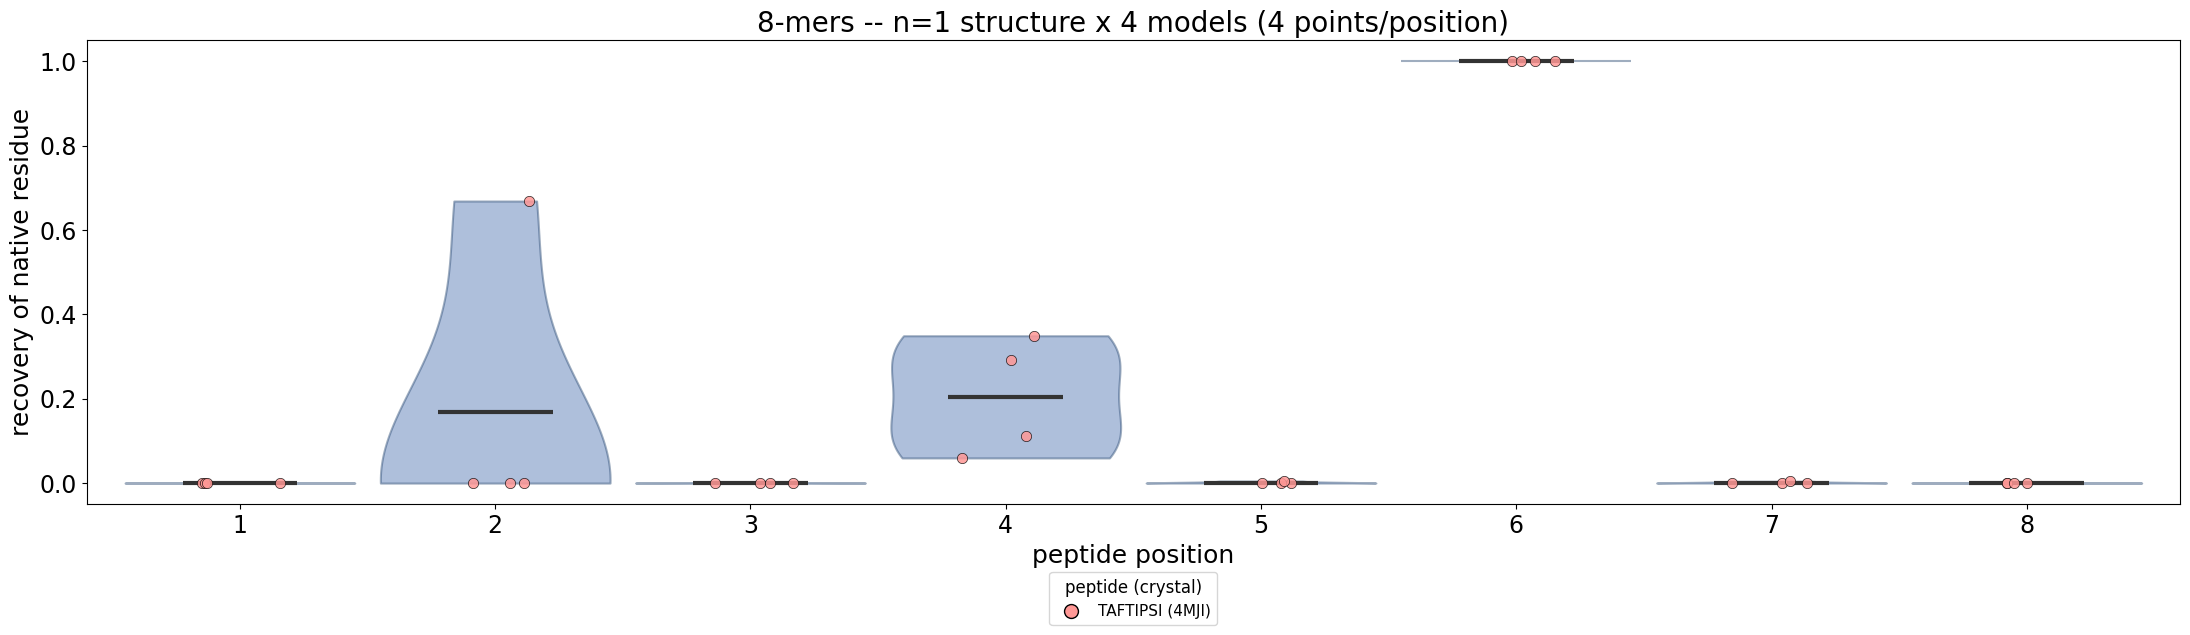

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_mhconly_8mer.png


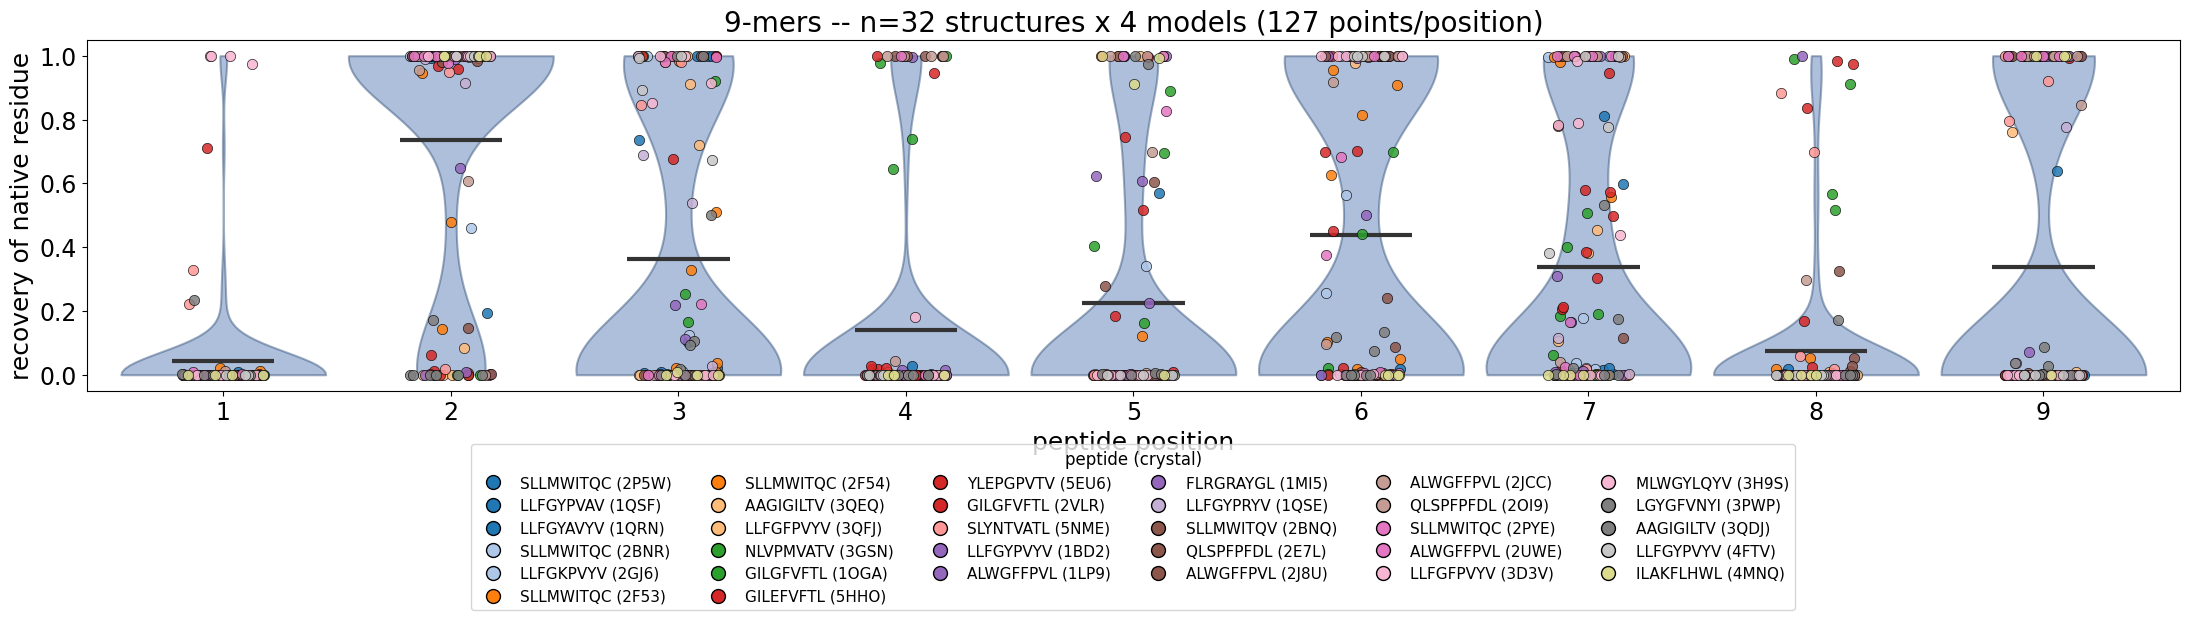

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_mhconly_9mer.png


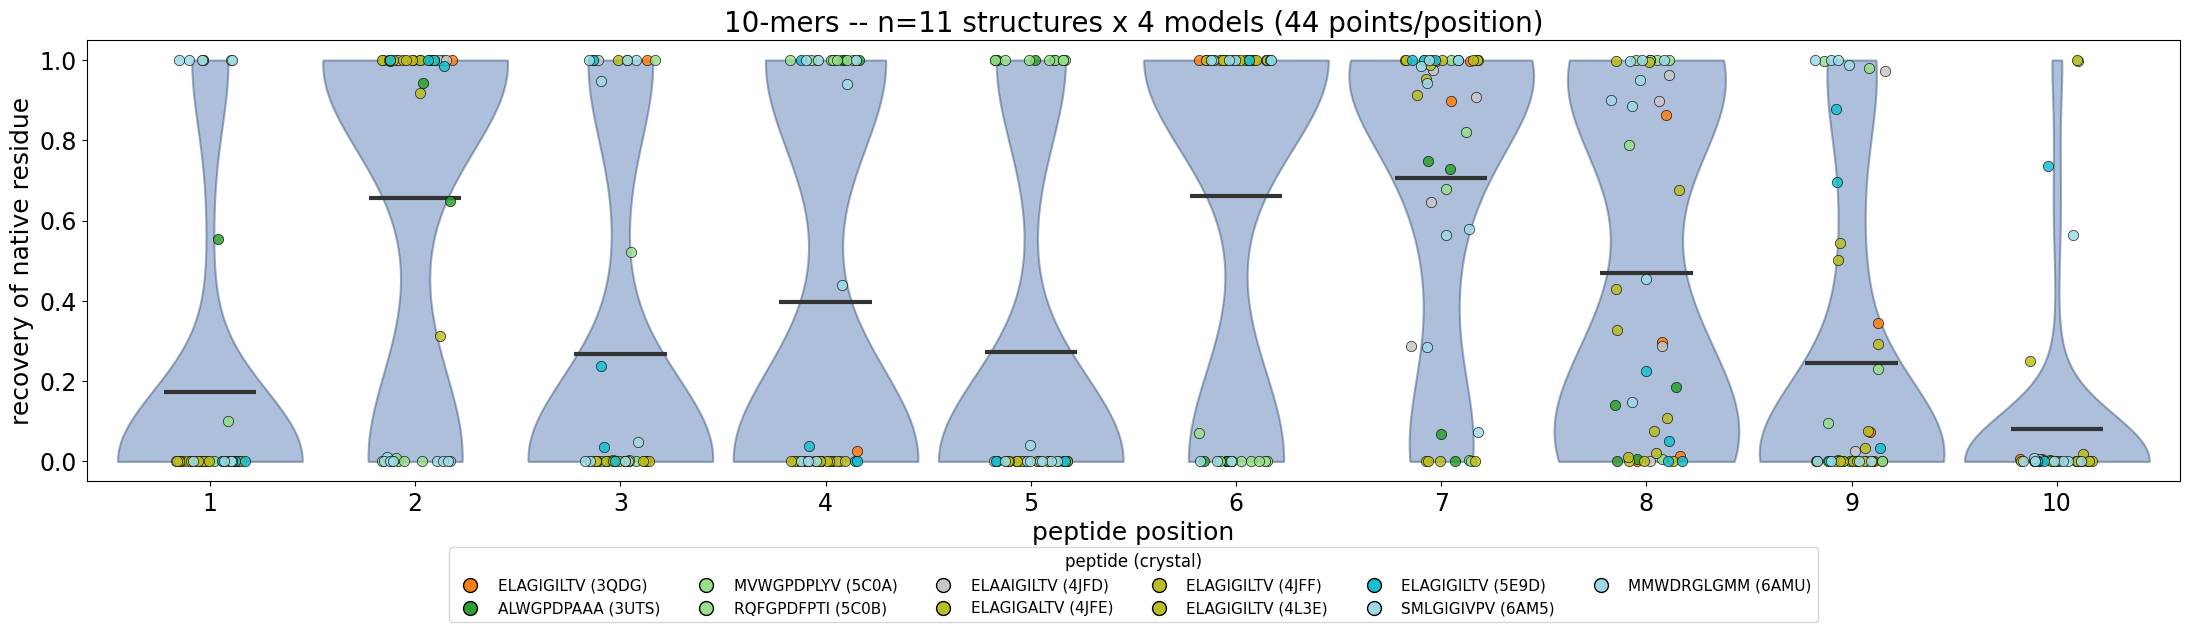

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_mhconly_10mer.png


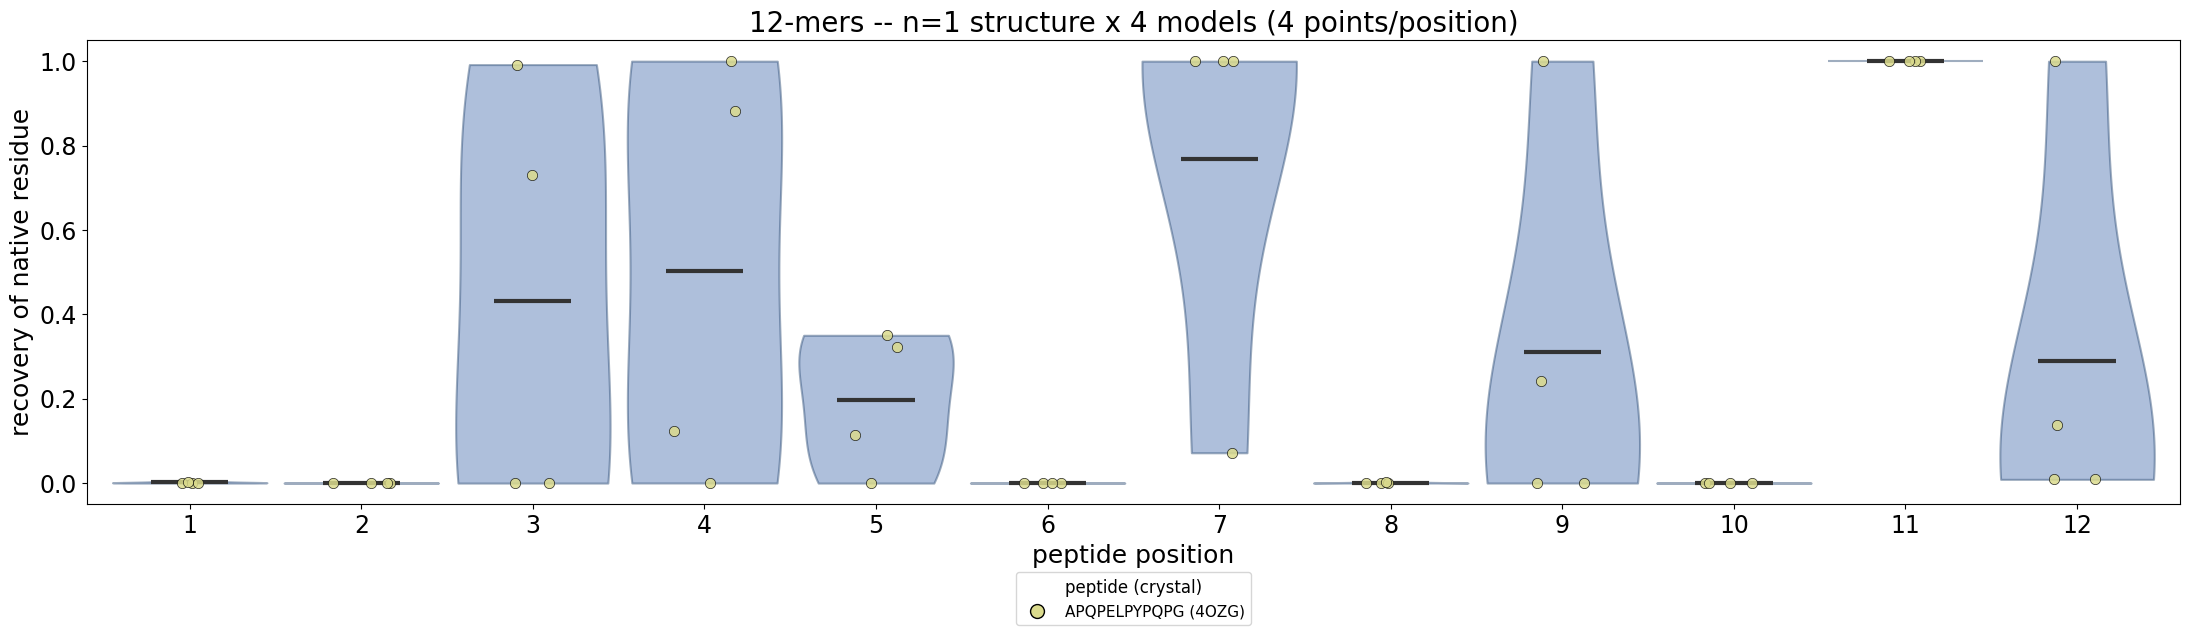

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_mhconly_12mer.png


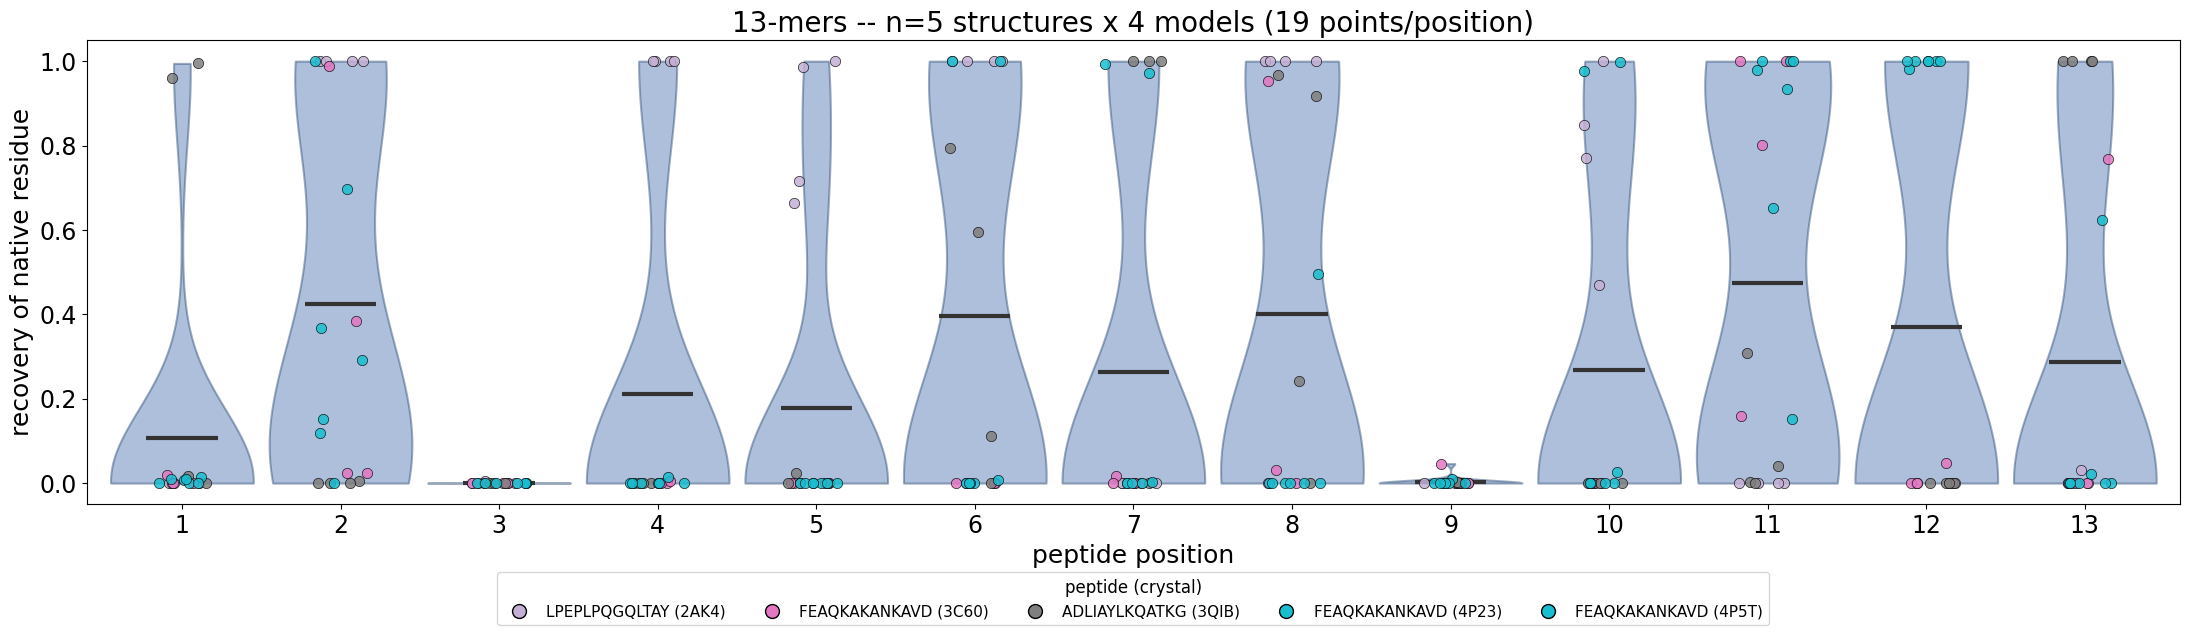

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_violin_summary_mhconly_13mer.png


In [4]:
max_len = max(len(natives[pdb]) for pdb in STRUCTS)
pdb_colors = {pdb: cm.tab20(i / max(len(STRUCTS), 1)) for i, pdb in enumerate(STRUCTS)}
rng_jitter = np.random.RandomState(0)

# one group per peptide length; positions only mean the same thing within a group
LENGTHS = sorted({len(natives[pdb]) for pdb in STRUCTS})
STRUCTS_BY_LEN = {L: [pdb for pdb in STRUCTS if len(natives[pdb]) == L] for L in LENGTHS}
print("peptide-length groups: "
      + ",  ".join(f"{L}-mer n={len(STRUCTS_BY_LEN[L])}" for L in LENGTHS))


def position_values(pdbs, cond, length):
    # {position -> [(recovery, pdb), ...]} over the given structures, skipping empty cells
    out = {p: [] for p in range(length)}
    for pdb in pdbs:
        mat = recovery_mat[(pdb, cond)]
        for pos in range(length):
            for j, _model in enumerate(MODELS):
                v = mat[pos, j]
                if np.isfinite(v):
                    out[pos].append((v, pdb))
    return out


for cond in CONDITIONS:
    for L in LENGTHS:
        fig, ax = plt.subplots(figsize=(22, 6.5))
        pdbs = STRUCTS_BY_LEN[L]
        by_pos = position_values(pdbs, cond, L)
        positions_with_data = [p for p in range(L) if by_pos[p]]
        data = [[v for v, _ in by_pos[p]] for p in positions_with_data]

        parts = ax.violinplot(data, positions=[p + 1 for p in positions_with_data], showmeans=True,
                              showextrema=False, widths=0.9)
        for pc in parts["bodies"]:
            pc.set_facecolor("#4C72B0"); pc.set_alpha(0.45)
            pc.set_edgecolor("#2A4A73"); pc.set_linewidth(1.5)
        if "cmeans" in parts:
            parts["cmeans"].set_color("#333333"); parts["cmeans"].set_linewidth(3)

        for p in positions_with_data:
            vals_pdbs = by_pos[p]
            xs = (p + 1) + rng_jitter.uniform(-0.18, 0.18, size=len(vals_pdbs))
            for (val, pdb), x in zip(vals_pdbs, xs):
                ax.scatter(x, val, s=55, alpha=0.85, color=pdb_colors[pdb],
                           edgecolors="black", linewidths=0.5, zorder=5)

        n_points = len(data[0]) if data else 0
        ax.set_xlabel("peptide position", fontsize=18)
        ax.set_ylabel("recovery of native residue", fontsize=18)
        ax.set_title(f"{L}-mers -- n={len(pdbs)} structure{'' if len(pdbs)==1 else 's'} "
                     f"x {len(MODELS)} models ({n_points} points/position)", fontsize=20)
        ax.set_xticks([p + 1 for p in positions_with_data])
        ax.set_xlim(0.4, L + 0.6)
        ax.set_ylim(-0.05, 1.05)
        ax.tick_params(axis="both", labelsize=17)
        handles = [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=pdb_colors[pdb],
                              markeredgecolor="black", markersize=10,
                              label=f"{natives[pdb]} ({pdb})") for pdb in pdbs]
        ax.legend(handles=handles, title="peptide (crystal)", fontsize=11, title_fontsize=12,
                  ncol=min(6, max(1, len(pdbs))), loc="upper center", bbox_to_anchor=(0.5, -0.13))

        fig.tight_layout()
        out = FIG_DIR / f"fig_panel3_violin_summary_{cond}_{L}mer.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"wrote {out}")

### 2a. Are P2 and P$\Omega$ significantly better recovered than non-anchor positions? (corrected test)

The naive version of this test (every position vs. "everything else," 10 exploratory tests) has two
real problems: (1) pseudoreplication -- pooling 4 models per crystal as if they were 80 independent
samples, when the true independent unit is the crystal (n=20); and (2) the "rest" baseline shifts and
is self-referential -- when testing P9, "rest" includes P2 (itself elevated); when testing P2, "rest"
includes P1/P9/P$\Omega$ (already known/suspected to be different), so every test contaminates every
other test's reference group. Fixed here: average across the 4 models first (one recovery value per
crystal x position, n=20 independent crystals), and compare the two pre-registered anchors -- P2
(pocket B) and P$\Omega$, each peptide's own C-terminal position (pocket F) -- against a **fixed**
reference group of interior, non-anchor positions (P3 through the second-to-last position, i.e.
excluding P1, P2, and P$\Omega$ from the reference group since P1 is already known to behave
unusually). Two pre-planned paired Wilcoxon tests, Bonferroni-corrected by 2, not 10.

pMHC+TCR -- P2 (n=50 crystals, model-averaged) vs. interior non-anchor positions: mean 0.65 vs. 0.50, p_raw=1.76e-02 (*), p_bonferroni=3.52e-02 (*)
pMHC+TCR -- P-Omega (n=50 crystals, model-averaged) vs. interior non-anchor positions: mean 0.26 vs. 0.50, p_raw=2.12e-04 (***), p_bonferroni=4.24e-04 (***)
pMHC only -- P2 (n=50 crystals, model-averaged) vs. interior non-anchor positions: mean 0.66 vs. 0.30, p_raw=1.37e-06 (***), p_bonferroni=2.73e-06 (***)
pMHC only -- P-Omega (n=50 crystals, model-averaged) vs. interior non-anchor positions: mean 0.27 vs. 0.30, p_raw=2.57e-01 (ns), p_bonferroni=5.14e-01 (ns)



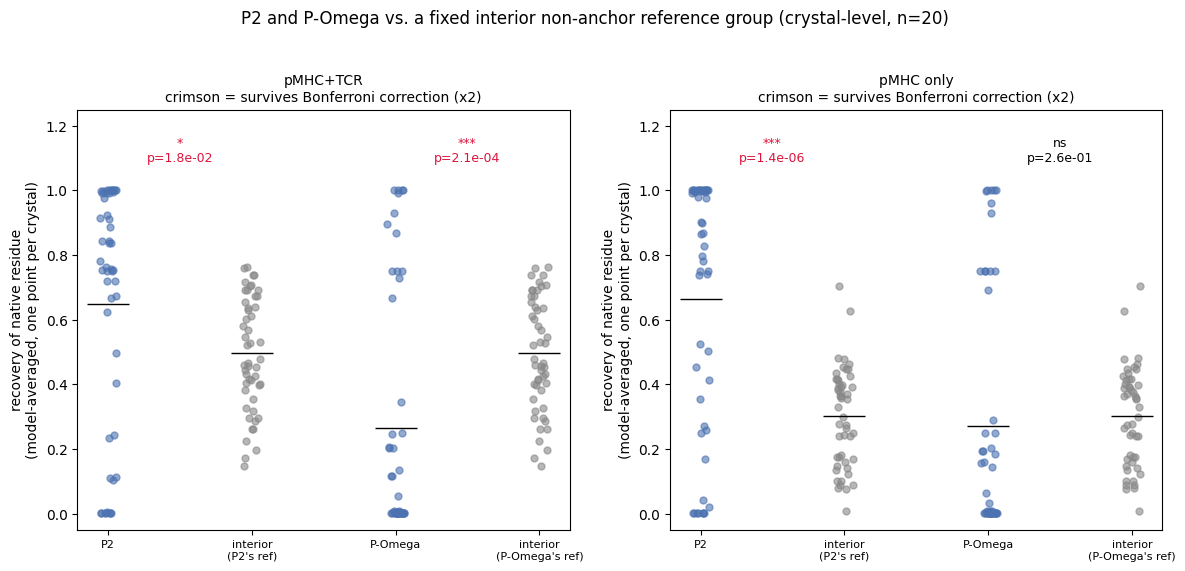

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_anchor_vs_nonanchor_corrected.png


In [5]:
def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return "ns"

def crystal_level_anchor_test(cond, use_omega):
    anchor_vals, ref_vals, pdbs_used = [], [], []
    for pdb in STRUCTS:
        length = len(natives[pdb])
        anchor_idx = (length - 1) if use_omega else 1  # P-Omega or literal P2 (0-indexed)
        excluded = {0, 1, length - 1}  # P1, P2, P-Omega excluded from the reference group
        ref_idx = [p for p in range(length) if p not in excluded]
        if not ref_idx or (use_omega and anchor_idx <= 1):
            continue
        mat = recovery_mat[(pdb, cond)]
        model_mean = np.nanmean(mat, axis=1)  # average across the 4 models -> one value per position
        if np.isnan(model_mean[anchor_idx]) or np.all(np.isnan(model_mean[ref_idx])):
            continue
        anchor_vals.append(model_mean[anchor_idx])
        ref_vals.append(np.nanmean(model_mean[ref_idx]))
        pdbs_used.append(pdb)
    return np.array(anchor_vals), np.array(ref_vals), pdbs_used

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for cond, ax in zip(CONDITIONS, axes):
    results = {}
    for label, use_omega in [("P2", False), ("P-Omega", True)]:
        anchor_vals, ref_vals, pdbs_used = crystal_level_anchor_test(cond, use_omega)
        stat, p_raw = wilcoxon(anchor_vals, ref_vals)
        p_adj = min(1.0, p_raw * 2)
        results[label] = (anchor_vals, ref_vals, p_raw, p_adj, pdbs_used)
        print(f"{COND_LABEL[cond]} -- {label} (n={len(anchor_vals)} crystals, model-averaged) vs. "
              f"interior non-anchor positions: mean {anchor_vals.mean():.2f} vs. {ref_vals.mean():.2f}, "
              f"p_raw={p_raw:.2e} ({sig_stars(p_raw)}), p_bonferroni={p_adj:.2e} ({sig_stars(p_adj)})")

    rng = np.random.RandomState(0)
    for i, label in enumerate(["P2", "P-Omega"]):
        anchor_vals, ref_vals, p_raw, p_adj, pdbs_used = results[label]
        for j, vals in enumerate([anchor_vals, ref_vals]):
            x = i * 2 + j + rng.uniform(-0.06, 0.06, size=len(vals))
            ax.scatter(x, vals, s=25, alpha=0.6, color="#4C72B0" if j == 0 else "#888888", zorder=3)
        m_anchor, m_ref = anchor_vals.mean(), ref_vals.mean()
        ax.plot([i * 2, i * 2 + 1], [m_anchor, m_ref], color="black", linewidth=0, marker="_",
               markersize=30, zorder=4)
        color = "crimson" if p_adj < 0.05 else "black"
        y_top = max(anchor_vals.max(), ref_vals.max())
        ax.text(i * 2 + 0.5, y_top + 0.08, f"{sig_stars(p_raw)}\np={p_raw:.1e}", ha="center",
               va="bottom", fontsize=9, color=color)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["P2", "interior\n(P2's ref)", "P-Omega", "interior\n(P-Omega's ref)"], fontsize=8)
    ax.set_ylabel("recovery of native residue\n(model-averaged, one point per crystal)")
    ax.set_ylim(-0.05, 1.25)
    ax.set_title(f"{COND_LABEL[cond]}\ncrimson = survives Bonferroni correction (x2)", fontsize=10)
print()
fig.suptitle("P2 and P-Omega vs. a fixed interior non-anchor reference group (crystal-level, n=20)", y=1.03)
fig.tight_layout()
out = FIG_DIR / "fig_panel3_anchor_vs_nonanchor_corrected.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

### 2b. Mean recovery per position, with bootstrap 95% CI (not SD)

SD describes how spread out the raw data is -- for data this bimodal, SD is inherently large and
mostly just re-reports "some points are 0, some are 1," the same problem as the violin's min/max
whiskers above. What actually matters for comparing positions is how precisely the **mean itself** is
known given the sample size at that position -- that's what a bootstrap confidence interval on the
mean answers, and unlike SD it shrinks as the effective sample size grows, rather than being dominated
by the bimodality of individual points. Computed via `scipy.stats.bootstrap` (percentile method,
9,999 resamples).

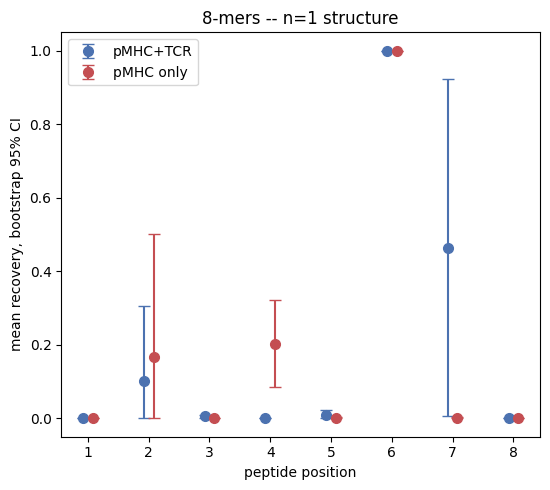

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_mean_bootstrap_ci_by_position_8mer.png


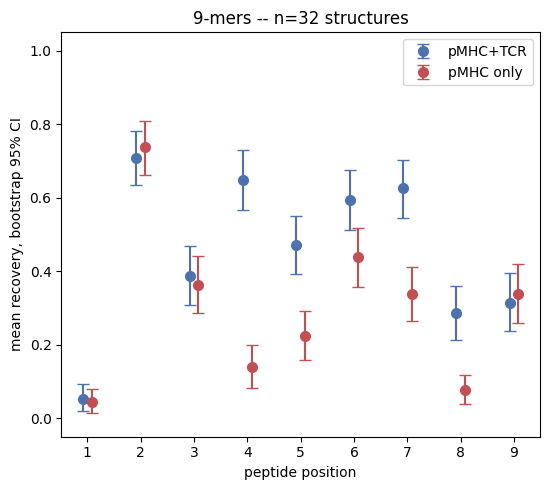

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_mean_bootstrap_ci_by_position_9mer.png


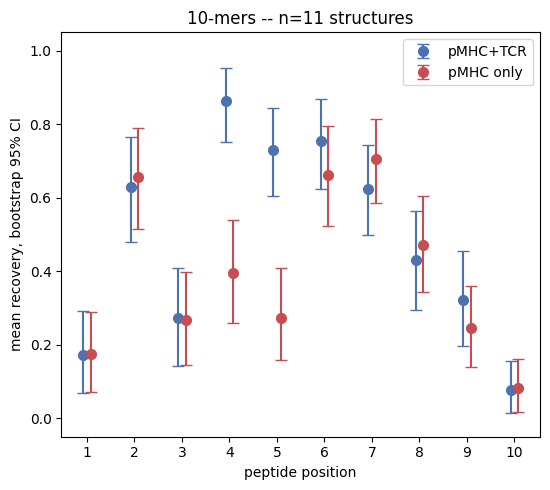

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_mean_bootstrap_ci_by_position_10mer.png


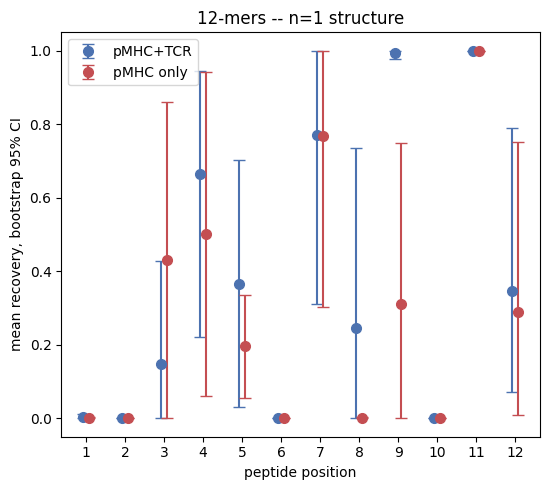

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_mean_bootstrap_ci_by_position_12mer.png


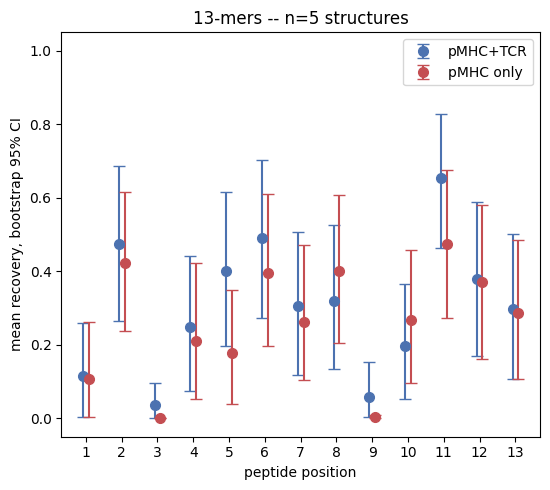

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_mean_bootstrap_ci_by_position_13mer.png


In [6]:
from scipy.stats import bootstrap as scipy_bootstrap

for L in LENGTHS:
    fig, ax = plt.subplots(figsize=(5.6, 5))
    pdbs = STRUCTS_BY_LEN[L]
    for cond, offset, color in [("full", -0.08, "#4C72B0"), ("mhconly", 0.08, "#C44E52")]:
        by_pos = position_values(pdbs, cond, L)
        positions_with_data = [p for p in range(L) if by_pos[p]]
        means, lower, upper = [], [], []
        for pos in positions_with_data:
            vals = np.array([v for v, _ in by_pos[pos]])
            m = vals.mean()
            if len(np.unique(vals)) > 1:
                res = scipy_bootstrap((vals,), np.mean, n_resamples=9999, confidence_level=0.95,
                                      method="percentile", random_state=0)
                lo, hi = res.confidence_interval
            else:
                lo = hi = m
            means.append(m); lower.append(m - lo); upper.append(hi - m)

        xs = [p + 1 + offset for p in positions_with_data]
        ax.errorbar(xs, means, yerr=[lower, upper], fmt="o", markersize=7, capsize=4, color=color,
                    label=COND_LABEL[cond])

    ax.set_xlabel("peptide position")
    ax.set_xticks(range(1, L + 1))
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"{L}-mers -- n={len(pdbs)} structure{'' if len(pdbs)==1 else 's'}")
    ax.set_ylabel("mean recovery, bootstrap 95% CI")
    ax.legend()
    fig.tight_layout()
    out = FIG_DIR / f"fig_panel3_recovery_mean_bootstrap_ci_by_position_{L}mer.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")

### 2c. Raincloud: half-violin + every raw point, one panel per position (1 row x 10 columns)

Density-coloring individual points (previous attempt) added little here -- the distribution is so
sharply bimodal (piled up almost exactly at 0 and 1, with only a handful of points anywhere in
between) that "brighter = denser" just re-states what's already obvious from the two clusters. A
raincloud plot instead shows the honest shape (a half-violin, which will plainly show two humps hugging
0 and 1 if that's what the data actually looks like) side by side with every individual point
(jittered strip, plain black) -- no smoothing hides any point, and no artificial averaging distorts the
shape.

/tmp/ipykernel_98734/1398654427.py:20: RuntimeWarning: invalid value encountered in divide
  w = density / density.max() * 0.34


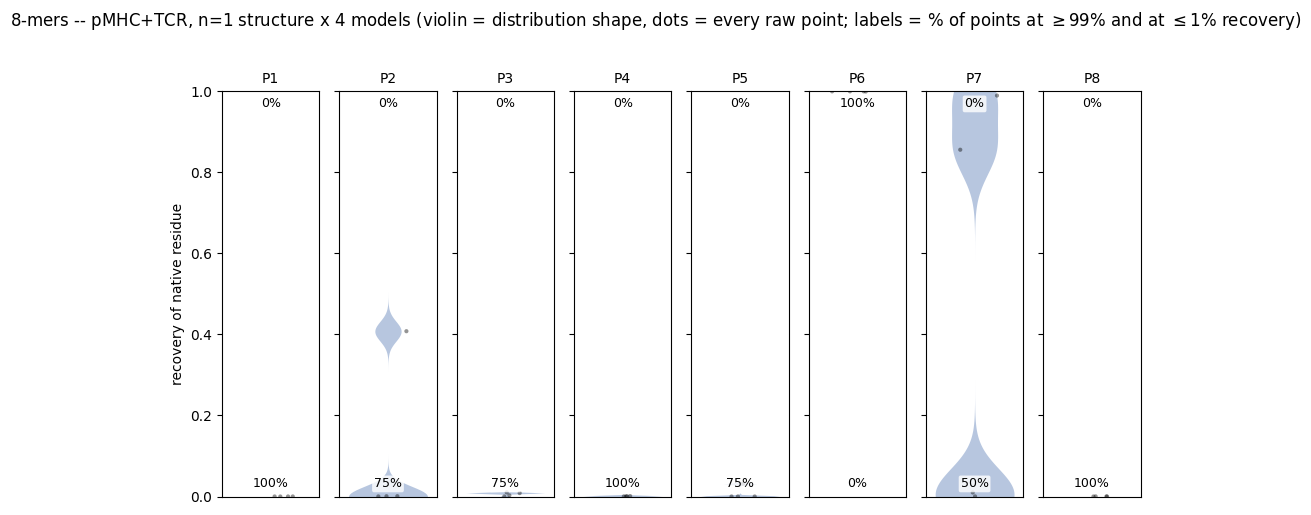

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_full_8mer.png


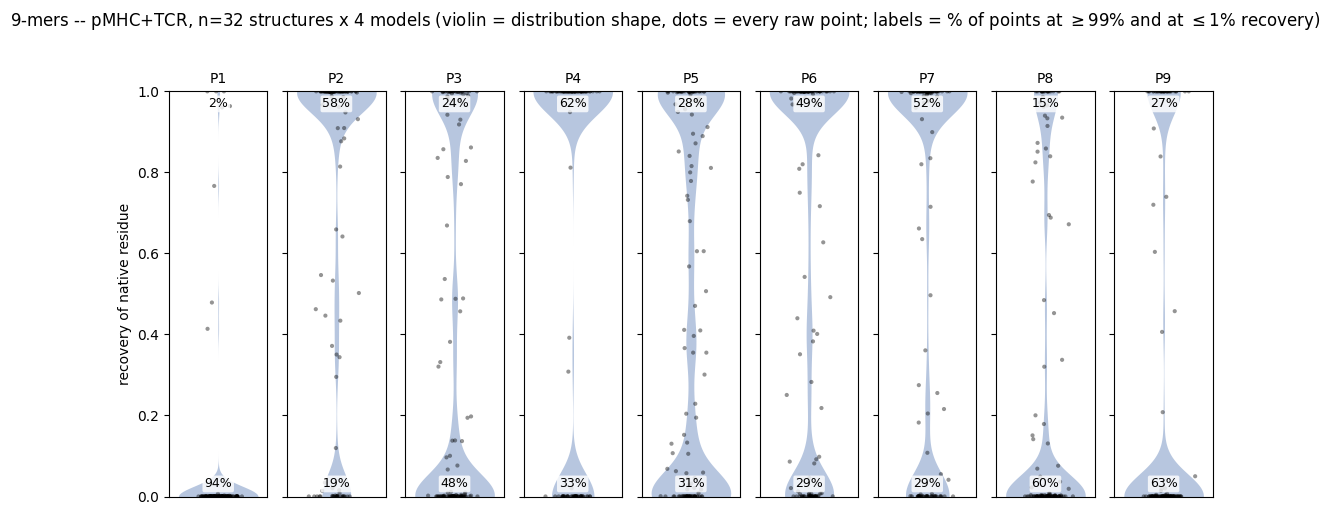

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_full_9mer.png


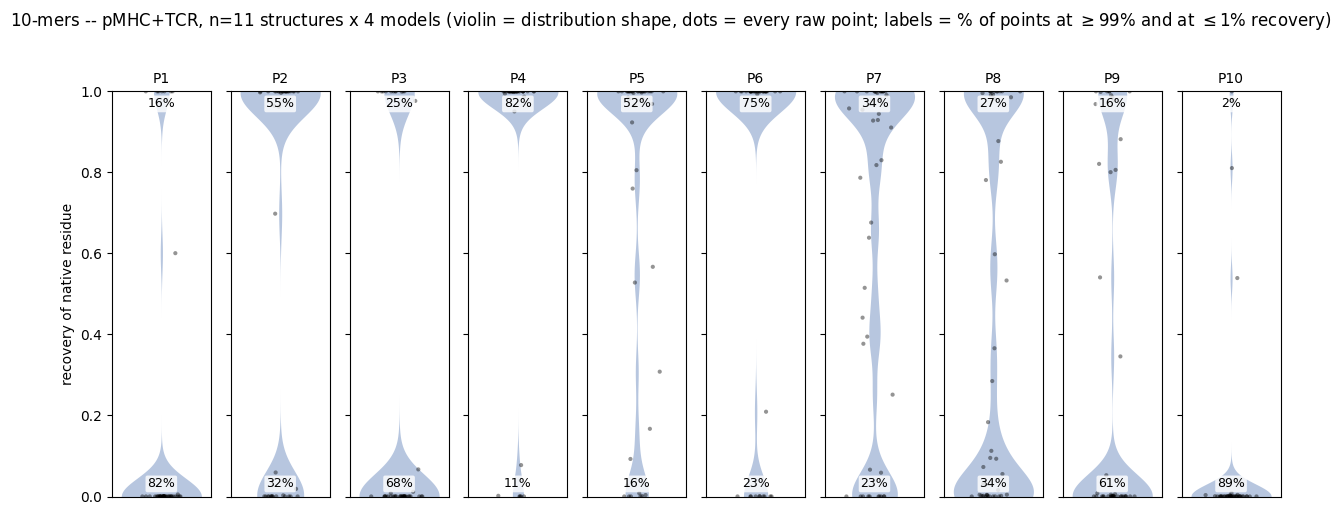

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_full_10mer.png


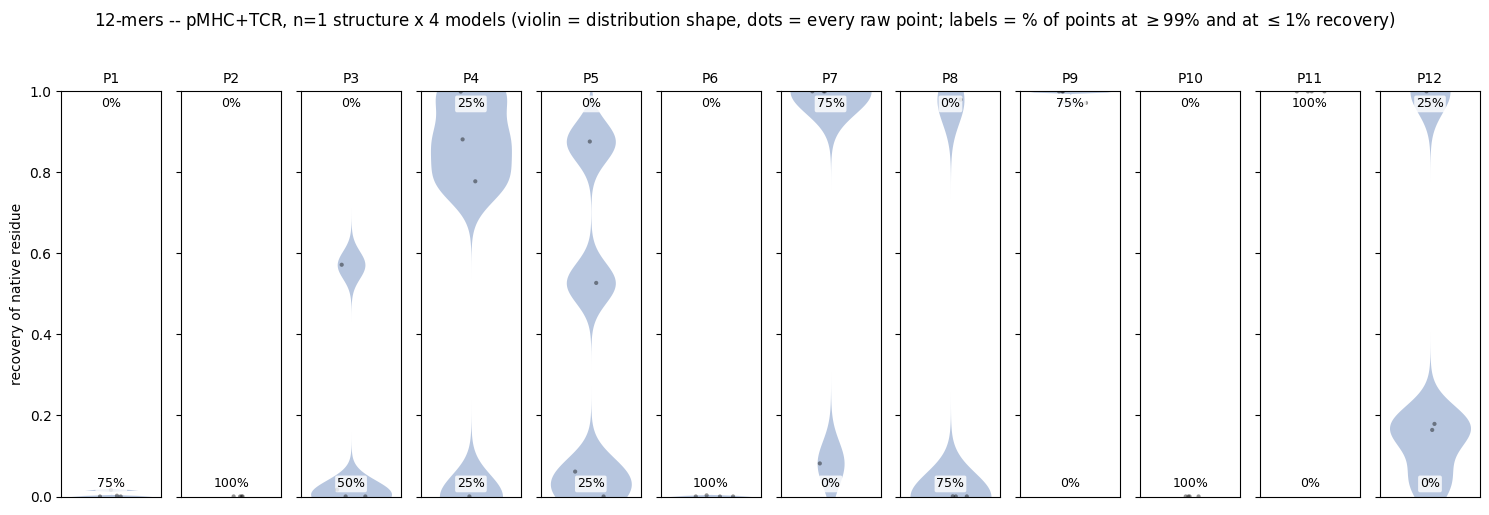

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_full_12mer.png


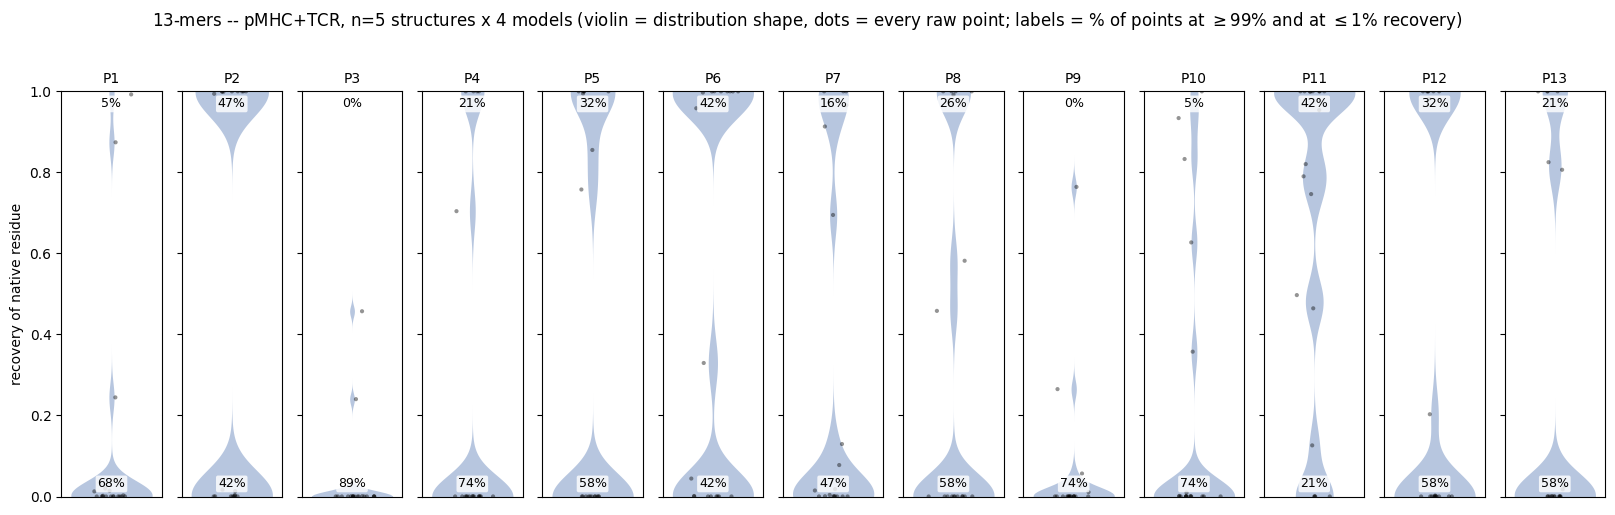

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_full_13mer.png


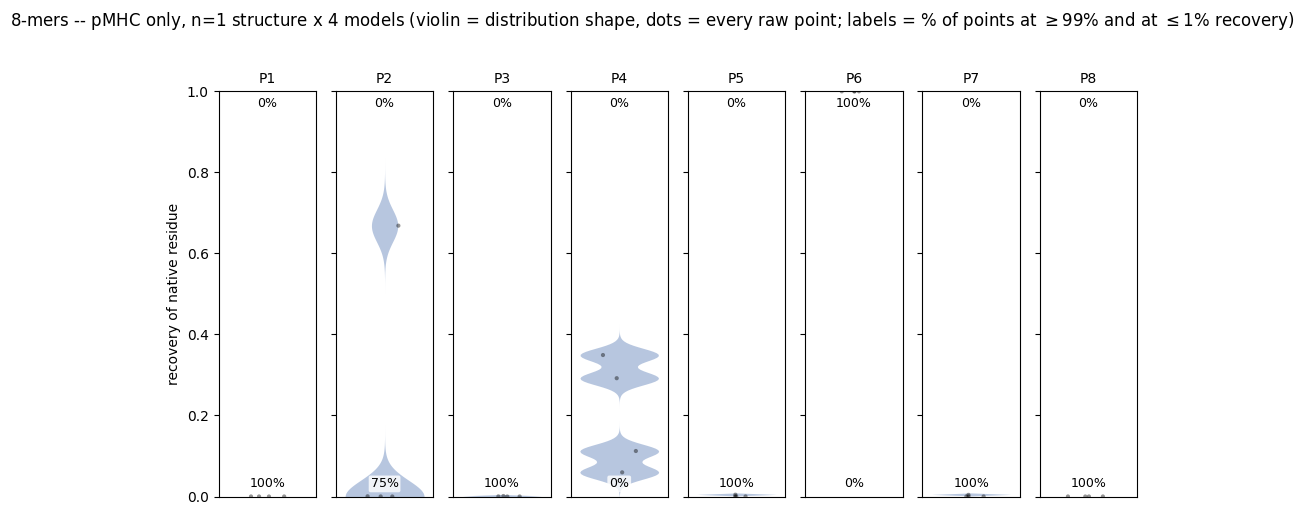

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_mhconly_8mer.png


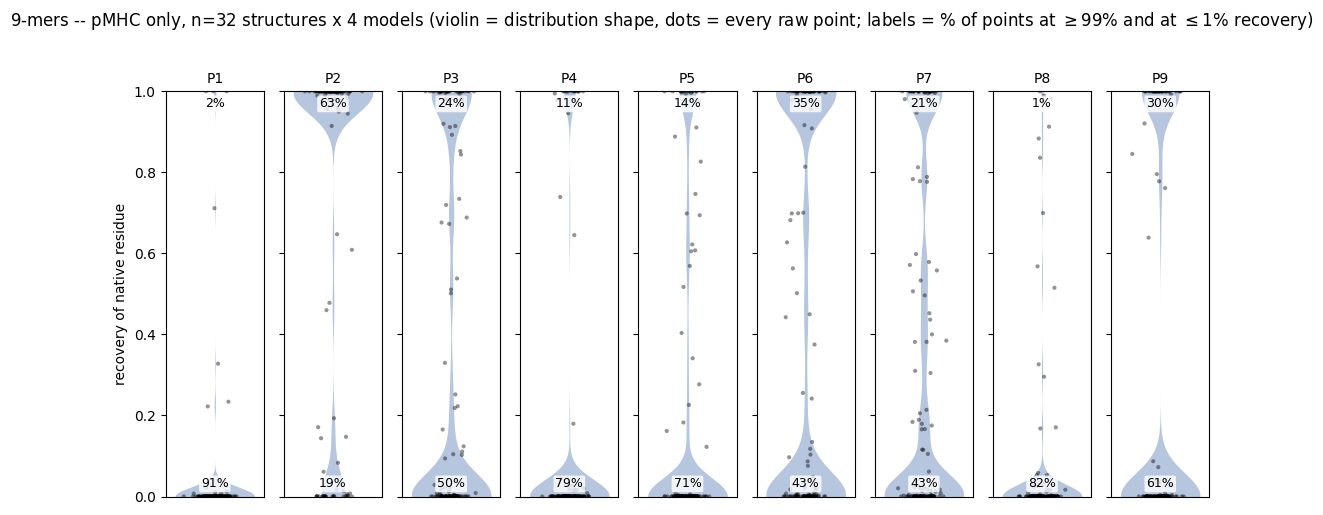

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_mhconly_9mer.png


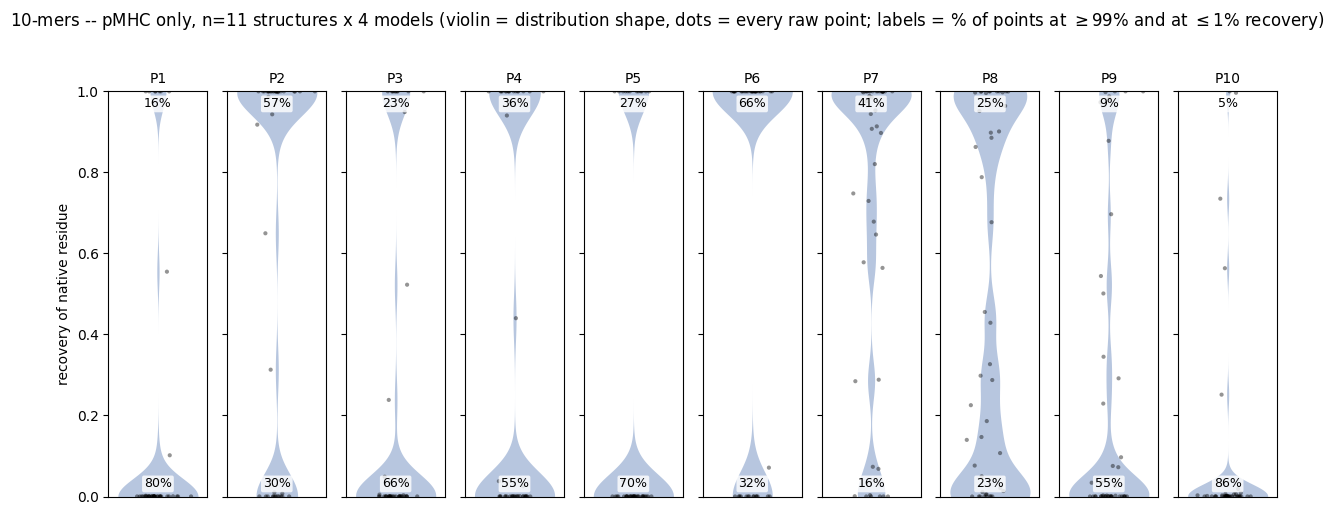

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_mhconly_10mer.png


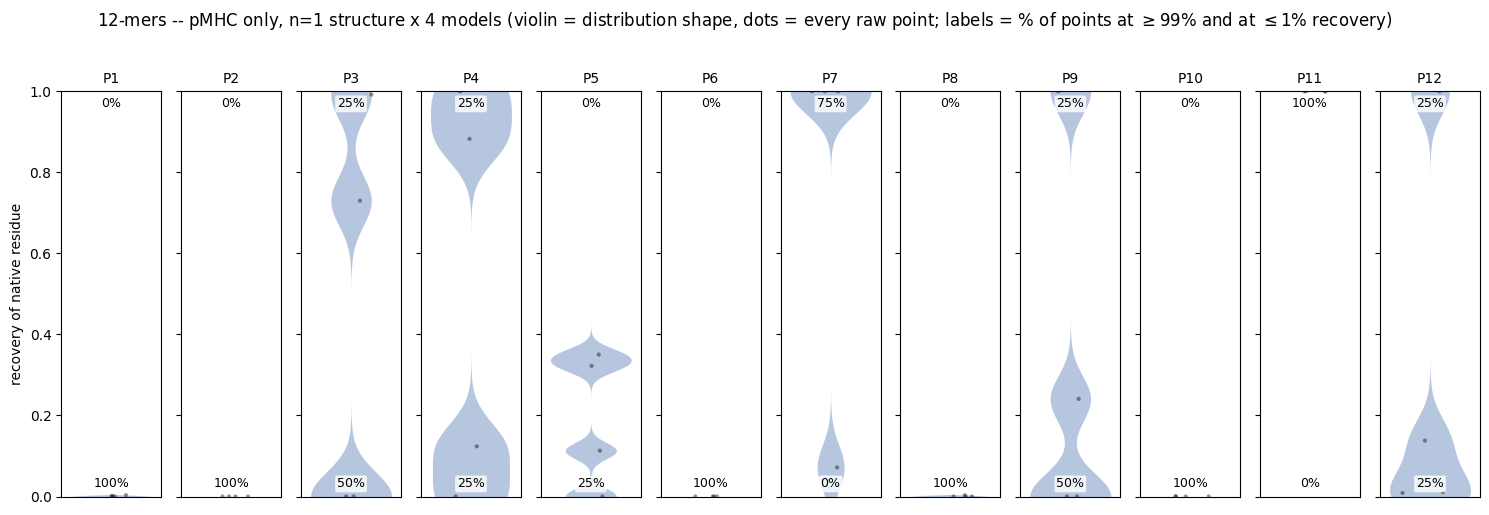

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_mhconly_12mer.png


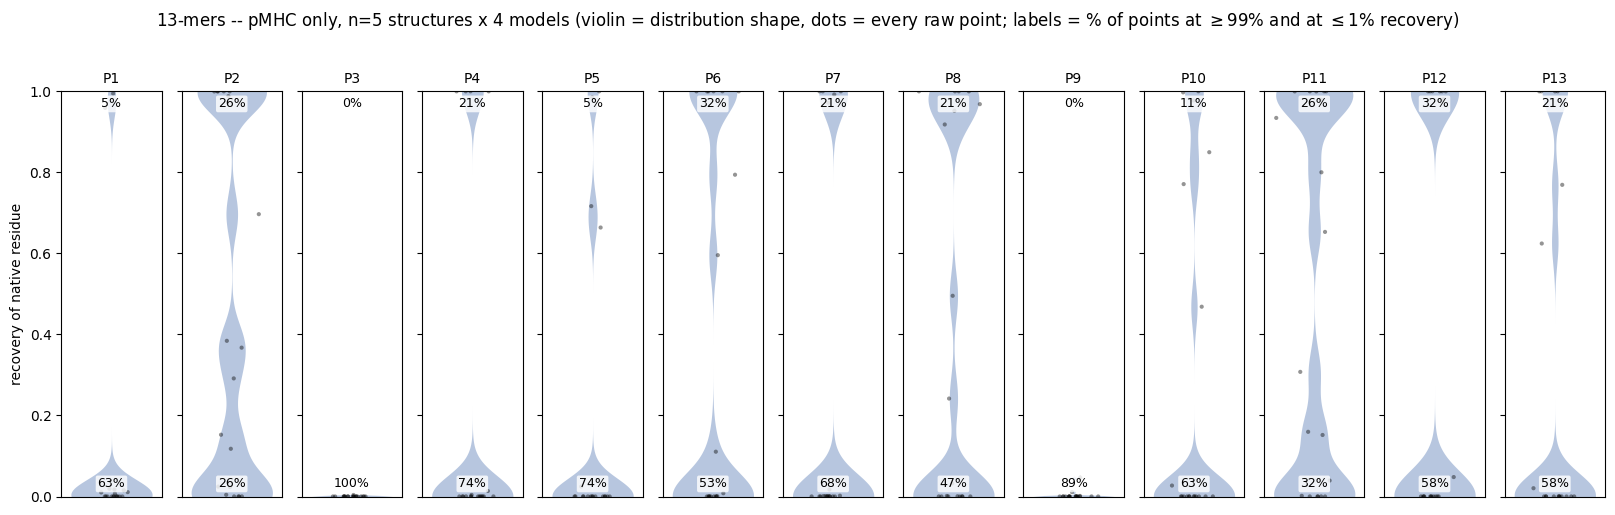

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_raincloud_mhconly_13mer.png


In [7]:
from scipy.stats import gaussian_kde

grid = np.linspace(-0.05, 1.05, 300)
rng_rain = np.random.RandomState(0)

for cond in CONDITIONS:
    for L in LENGTHS:
        pdbs = STRUCTS_BY_LEN[L]
        by_pos = position_values(pdbs, cond, L)
        fig, axes = plt.subplots(1, L, figsize=(1.25 * L, 5.0), squeeze=False, sharey=True)
        axes = axes[0]
        for col in range(L):
            ax = axes[col]
            if not by_pos[col]:
                ax.axis("off")
                continue
            vals = np.array([v for v, _ in by_pos[col]])
            if len(np.unique(vals)) > 1:
                density = gaussian_kde(vals, bw_method=0.12)(grid)
                w = density / density.max() * 0.34
                ax.fill_betweenx(grid, -w, w, color="#4C72B0", alpha=0.40, linewidth=0)
            # points sit on the density rather than beside it: a side-by-side strip doubles
            # the panel width, and colouring points by crystal is unreadable at this count
            xs = rng_rain.normal(0.0, 0.085, size=len(vals))
            ax.scatter(xs, vals, s=9, color="black", alpha=0.42, edgecolor="none", zorder=3)
            ax.set_xlim(-0.42, 0.42)
            # the distribution is bimodal, so the two piles are the informative summary:
            # what fraction of (crystal, model) cells recover this position always, or never.
            # Thresholded at 1% rather than tested for exact equality: ProteinMPNN and
            # LigandMPNN echo the input sequence back as their first FASTA record, which puts a
            # floor of 1/9984 on those models and would make "exactly 0" reachable only by
            # ESM-IF1 -- an artifact of the output format, not a property of the designs.
            frac_top = np.mean(vals >= 0.99)
            frac_bot = np.mean(vals <= 0.01)
            ax.text(0.5, 0.985, f"{100 * frac_top:.0f}%", transform=ax.transAxes,
                    ha="center", va="top", fontsize=9, color="black",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.8,
                              edgecolor="none"))
            ax.text(0.5, 0.015, f"{100 * frac_bot:.0f}%", transform=ax.transAxes,
                    ha="center", va="bottom", fontsize=9, color="black",
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.8,
                              edgecolor="none"))
            ax.set_xticks([])
            ax.set_title(f"P{col + 1}", fontsize=10)
        axes[0].set_ylim(0, 1)
        axes[0].set_ylabel("recovery of native residue", fontsize=10)
        fig.suptitle(f"{L}-mers -- {COND_LABEL[cond]}, n={len(pdbs)} "
                     f"structure{'' if len(pdbs)==1 else 's'} x {len(MODELS)} models "
                     f"(violin = distribution shape, dots = every raw point; "
                     f"labels = % of points at $\\geq$99% and at $\\leq$1% recovery)", y=1.02)
        fig.tight_layout()
        out = FIG_DIR / f"fig_panel3_recovery_raincloud_{cond}_{L}mer.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"wrote {out}")

## 3. Correlation between models at specific sites

Per-position recovery, pooled across all 20 crystals x up to 10 positions each: do models succeed or
fail at the same specific sites, or are they capturing different signals?

full: pooled shape=(483, 4)


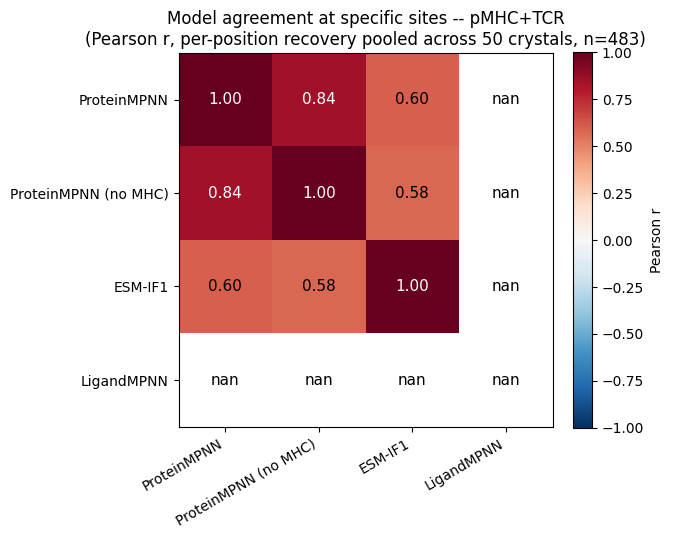

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_model_correlation_sites_full.png
                      ProteinMPNN  ProteinMPNN (no MHC)  ESM-IF1  LigandMPNN
ProteinMPNN                  1.00                  0.84     0.60         NaN
ProteinMPNN (no MHC)         0.84                  1.00     0.58         NaN
ESM-IF1                      0.60                  0.58     1.00         NaN
LigandMPNN                    NaN                   NaN      NaN         NaN

mhconly: pooled shape=(483, 4)


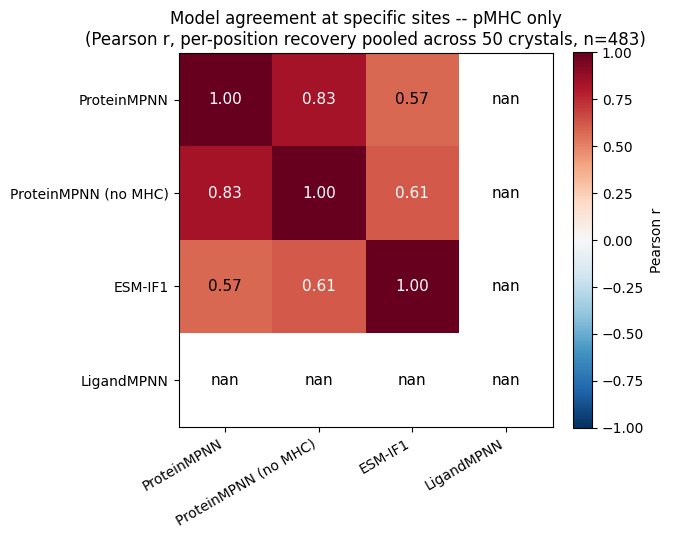

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_model_correlation_sites_mhconly.png
                      ProteinMPNN  ProteinMPNN (no MHC)  ESM-IF1  LigandMPNN
ProteinMPNN                  1.00                  0.83     0.57         NaN
ProteinMPNN (no MHC)         0.83                  1.00     0.61         NaN
ESM-IF1                      0.57                  0.61     1.00         NaN
LigandMPNN                    NaN                   NaN      NaN         NaN



In [8]:
from scipy.stats import pearsonr

for cond in CONDITIONS:
    pooled = np.vstack([recovery_mat[(pdb, cond)] for pdb in STRUCTS])
    corr = np.corrcoef(pooled.T)
    print(f"{cond}: pooled shape={pooled.shape}")

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    model_labels = [MODEL_LABEL[m] for m in MODELS]
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(model_labels, rotation=30, ha="right")
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(model_labels)
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                    color="white" if abs(corr[i, j]) > 0.6 else "black", fontsize=11)
    ax.set_title(f"Model agreement at specific sites -- {COND_LABEL[cond]}\n"
                 f"(Pearson r, per-position recovery pooled across {len(STRUCTS)} crystals, "
                 f"n={pooled.shape[0]})")
    fig.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
    fig.tight_layout()
    out = FIG_DIR / f"fig_panel3_model_correlation_sites_{cond}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"wrote {out}")
    print(pd.DataFrame(corr, index=model_labels, columns=model_labels).round(2))
    print()

## 4. Diversity model agreement

Do models agree on WHICH crystals are more or less diverse (unique-peptide fraction), or is diversity
essentially idiosyncratic per model?

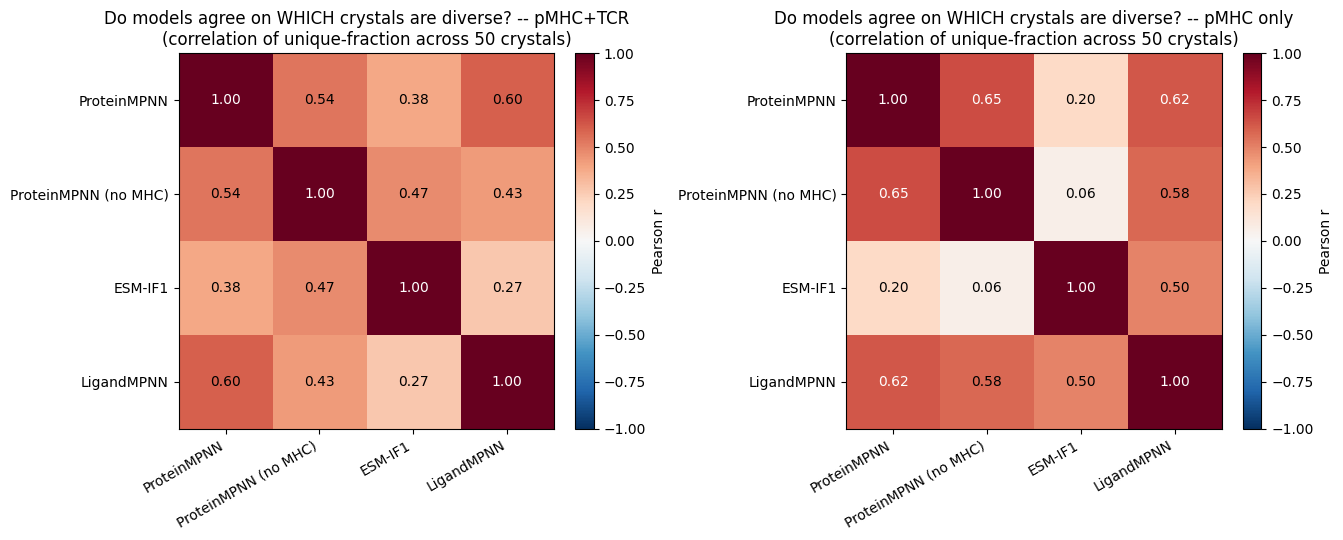

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_diversity_model_agreement.png


In [9]:
records = []
for cond in CONDITIONS:
    for pdb in STRUCTS:
        df = designs[(pdb, cond)]
        length = len(natives[pdb])
        for model in MODELS:
            peps = [p for p in df.loc[df.model == model, "peptide"] if len(p) == length]
            if not peps:
                continue
            records.append({"pdb": pdb, "condition": cond, "model": model,
                            "unique_frac": len(set(peps)) / len(peps)})
div_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))
for ax, cond in zip(axes, CONDITIONS):
    sub = div_df[div_df.condition == cond]
    pivot = sub.pivot(index="pdb", columns="model", values="unique_frac")[MODELS]  # enforce MODELS order
    corr = pivot.corr()
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    model_labels = [MODEL_LABEL[m] for m in MODELS]
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(model_labels, rotation=30, ha="right")
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(model_labels)
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            v = corr.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    color="white" if abs(v) > 0.6 else "black", fontsize=10)
    ax.set_title(f"Do models agree on WHICH crystals are diverse? -- {COND_LABEL[cond]}\n"
                 f"(correlation of unique-fraction across {len(STRUCTS)} crystals)")
    fig.colorbar(im, ax=ax, fraction=0.046, label="Pearson r")
fig.tight_layout()
out = FIG_DIR / "fig_panel3_diversity_model_agreement.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 5. Mean recovery vs. native peptide -- pMHC only, for direct comparison to Section 1

Same layout as Section 1 (models x crystals, transposed), mhconly context this time.

Friedman test across models (paired by structure, n=48): chi2=19.38, p=0.000 -- models differ


/tmp/ipykernel_98734/2242520687.py:4: RuntimeWarning: Mean of empty slice
  mat[:, j] = np.nanmean(recovery_mat[(pdb, cond)], axis=0)


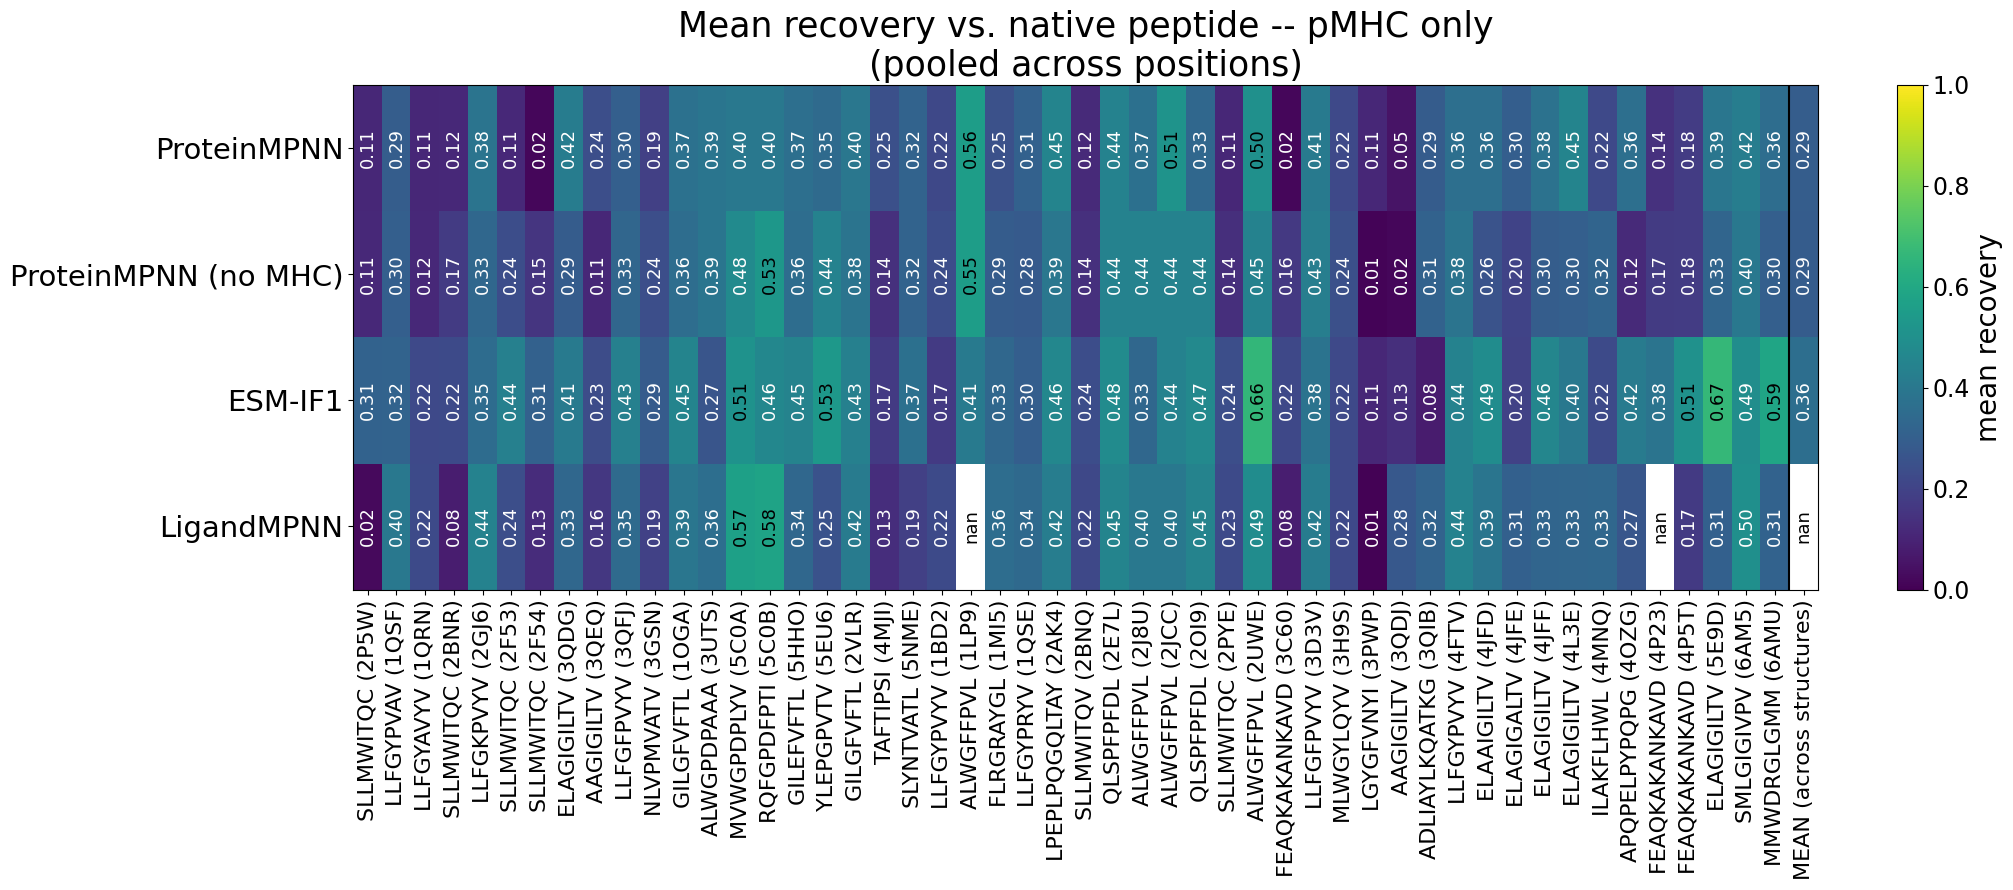

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_mean_recovery_mhconly.png


In [10]:
mat_mhconly = mean_recovery_matrix("mhconly")
plot_mean_recovery_heatmap(mat_mhconly, "Mean recovery vs. native peptide -- pMHC only\n"
                           "(pooled across positions)", "fig_panel3_mean_recovery_mhconly.png",
                           add_mean_col=True)

## 6. Where does the TCR-context benefit actually concentrate, crystal by crystal?

Delta = mean recovery(full) $-$ mean recovery(mhconly), one cell per (model, crystal). Positive
(red) = TCR context helps that crystal/model; negative (blue) = it hurts. This is the same
manipulation behind Section 3.1 of the paper's region-binned bar chart, but broken out per crystal
instead of pooled -- do all 20 crystals benefit from TCR context roughly equally, or is the benefit
driven by a handful of crystals? Crystals ordered left-to-right by resolution (best to worst) instead
of the arbitrary panel order, to see whether the benefit itself tracks crystal quality.

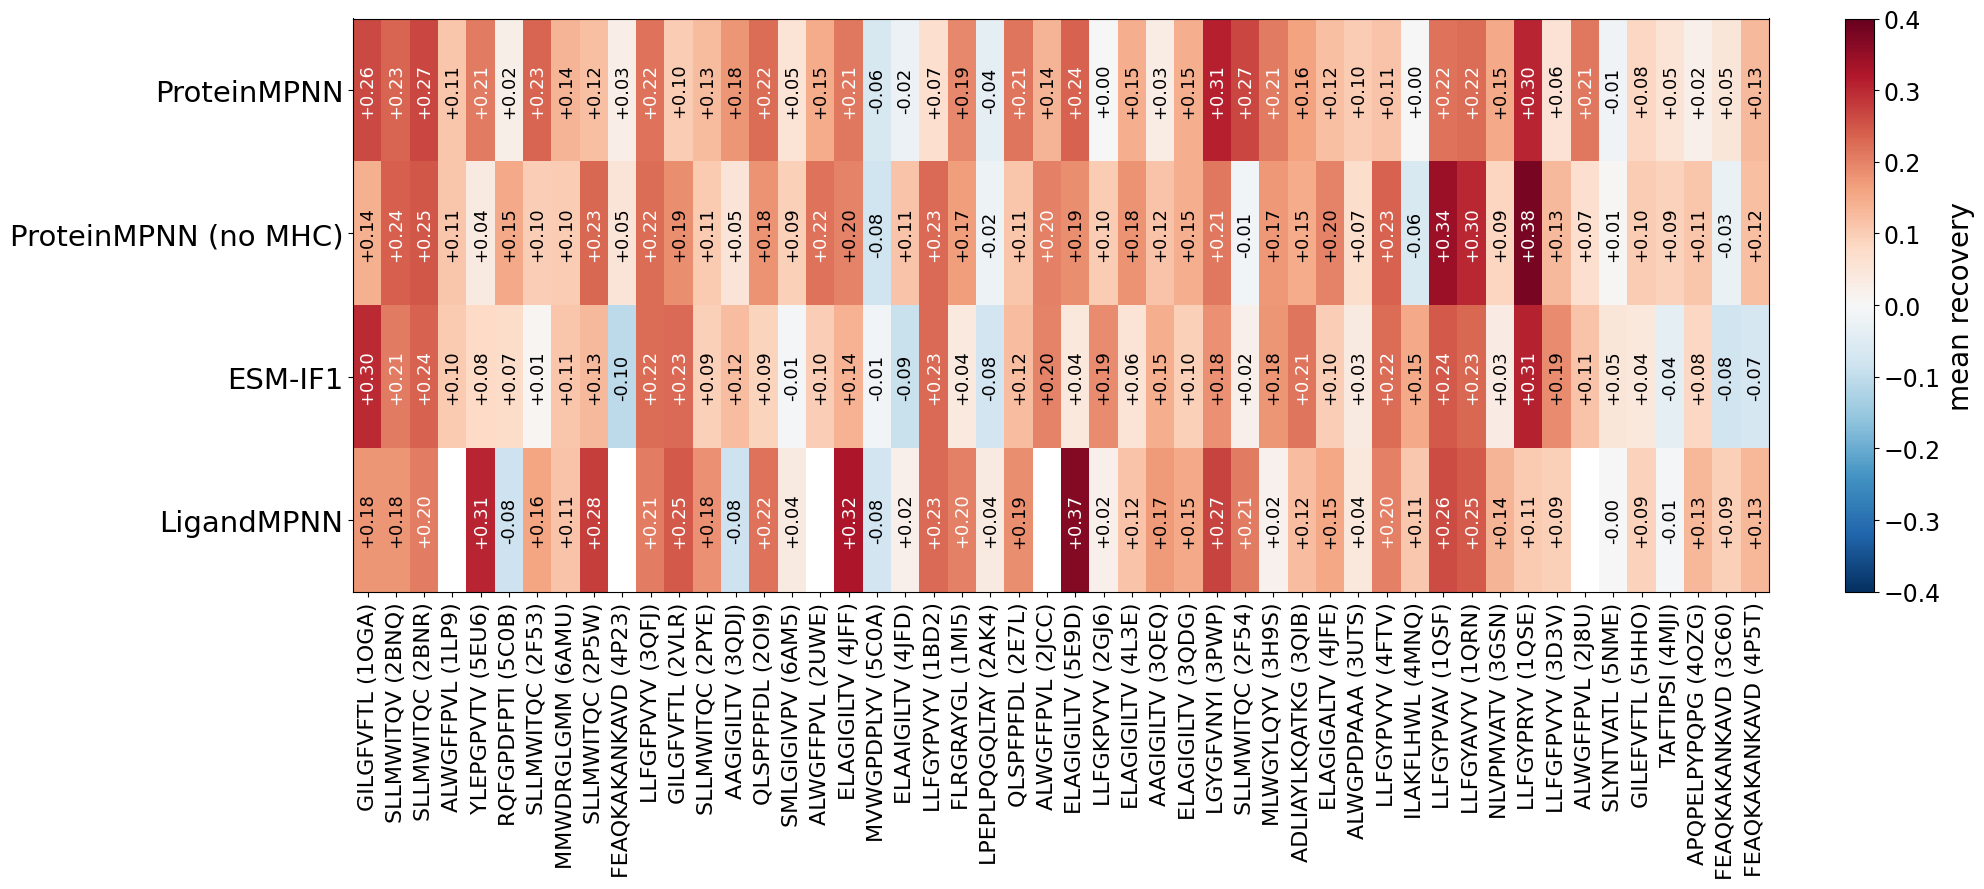

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_delta_recovery_heatmap.png
173/200 (model, crystal) cells favor full-context (positive delta)
mean delta = nan, per-crystal mean delta range: nan to nan

crystals, best to worst resolution: ['1OGA', '2BNQ', '2BNR', '1LP9', '5EU6', '5C0B', '2F53', '6AMU', '2P5W', '4P23', '3QFJ', '2VLR', '2PYE', '3QDJ', '2OI9', '6AM5', '2UWE', '4JFF', '5C0A', '4JFD', '1BD2', '1MI5', '2AK4', '2E7L', '2JCC', '5E9D', '2GJ6', '4L3E', '3QEQ', '3QDG', '3PWP', '2F54', '3H9S', '3QIB', '4JFE', '3UTS', '4FTV', '4MNQ', '1QSF', '1QRN', '3GSN', '1QSE', '3D3V', '2J8U', '5NME', '5HHO', '4MJI', '4OZG', '3C60', '4P5T']


In [11]:
quality_lookup = pd.read_csv(ROOT / "outputs/analysis/panel_dataset_master_table.csv").set_index(
    "pdb")["resolution_A"]
pdb_by_resolution = sorted(STRUCTS, key=lambda pdb: quality_lookup.loc[pdb])

delta_mat = mat_full - mat_mhconly
plot_mean_recovery_heatmap(delta_mat, "",   # title lives in the paper caption instead
                           "fig_panel3_delta_recovery_heatmap.png",
                           cmap="RdBu_r", vmin=-0.4, vmax=0.4, fmt="{:+.2f}", center_white=0.2,
                           pdb_order=pdb_by_resolution)
n_positive = (delta_mat > 0).sum()
n_total = delta_mat.size
print(f"{n_positive}/{n_total} (model, crystal) cells favor full-context (positive delta)")
print(f"mean delta = {delta_mat.mean():.3f}, per-crystal mean delta range: "
      f"{delta_mat.mean(axis=0).min():.3f} to {delta_mat.mean(axis=0).max():.3f}")
print(f"\ncrystals, best to worst resolution: {pdb_by_resolution}")

## 7. Does peptide length confound recovery?

Mean recovery vs. peptide length, one point per (crystal, model), colored by model. Peptide length was
already flagged as a possible confound in the paper (Pearson $r=0.36$ pooling all cells); here it's
shown directly, per model, to see whether the effect is uniform across tools or concentrated in one.

/tmp/ipykernel_98734/254479053.py:10: RuntimeWarning: Mean of empty slice
  "mean_recovery": np.nanmean(mat[:, j])})


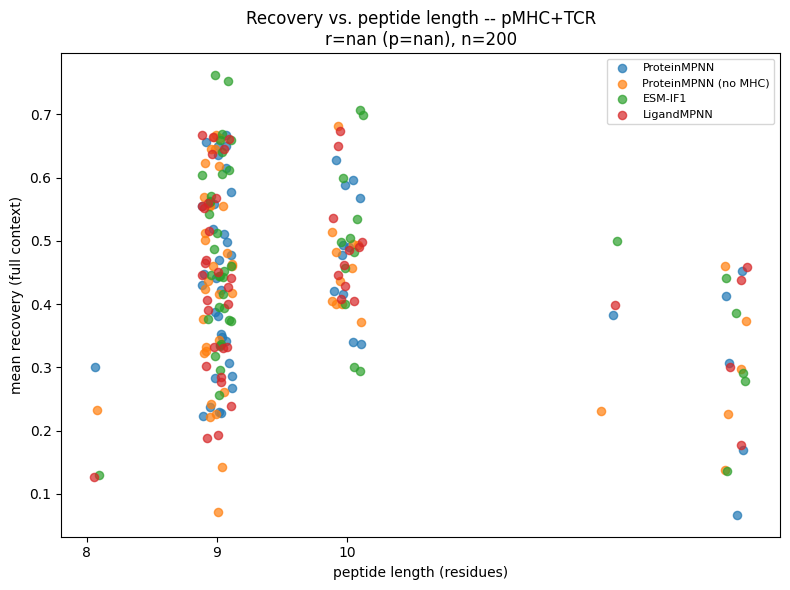

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_vs_length.png
model    ESM-IF1  LigandMPNN     noMHC   vanilla
length                                          
8       0.150065    0.130077  0.185785  0.272498
9       0.417494    0.364039  0.366317  0.355893
10      0.473222    0.445696  0.405089  0.437442
12      0.458287    0.332152  0.175439  0.373418
13      0.318054    0.295862  0.271971  0.248954


In [12]:
from scipy.stats import pearsonr as _pearsonr

length_records = []
for pdb in STRUCTS:
    length = len(natives[pdb])
    for cond in CONDITIONS:
        mat = recovery_mat[(pdb, cond)]
        for j, model in enumerate(MODELS):
            length_records.append({"pdb": pdb, "condition": cond, "model": model, "length": length,
                                   "mean_recovery": np.nanmean(mat[:, j])})
length_df = pd.DataFrame(length_records)

fig, ax = plt.subplots(figsize=(8, 6))
rng_len = np.random.RandomState(0)
for model in MODELS:
    sub = length_df[(length_df.model == model) & (length_df.condition == "full")]
    jitter = rng_len.uniform(-0.12, 0.12, size=len(sub))
    ax.scatter(sub["length"] + jitter, sub["mean_recovery"], label=MODEL_LABEL[model], alpha=0.7, s=35)
r, p = _pearsonr(length_df.loc[length_df.condition == "full", "length"],
                 length_df.loc[length_df.condition == "full", "mean_recovery"])
ax.set_xlabel("peptide length (residues)")
ax.set_ylabel("mean recovery (full context)")
ax.set_xticks([8, 9, 10])
ax.set_title(f"Recovery vs. peptide length -- pMHC+TCR\nr={r:.2f} (p={p:.2e}), "
             f"n={(length_df.condition == 'full').sum()}")
ax.legend(fontsize=8)
fig.tight_layout()
out = FIG_DIR / "fig_panel3_recovery_vs_length.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(length_df.groupby(["length", "model"])["mean_recovery"].mean().unstack())

## 8. 9-mers only: per-position contacts vs. recovery, one panel per residue

Restricted to the fifteen 9-mer crystals (the dominant length class). One panel per peptide position
(3x3 grid): $x$ = atom contacts at that specific residue ($<5$\AA{}, TCR+MHC combined, one value per
crystal -- a structural property, condition-independent), $y$ = recovery at that residue (one value
per crystal x model x condition).

32 nine-mer crystals: ['2P5W', '1QSF', '1QRN', '2BNR', '2GJ6', '2F53', '2F54', '3QEQ', '3QFJ', '3GSN', '1OGA', '5HHO', '5EU6', '2VLR', '5NME', '1BD2', '1LP9', '1MI5', '1QSE', '2BNQ', '2E7L', '2J8U', '2JCC', '2OI9', '2PYE', '2UWE', '3D3V', '3H9S', '3PWP', '3QDJ', '4FTV', '4MNQ']


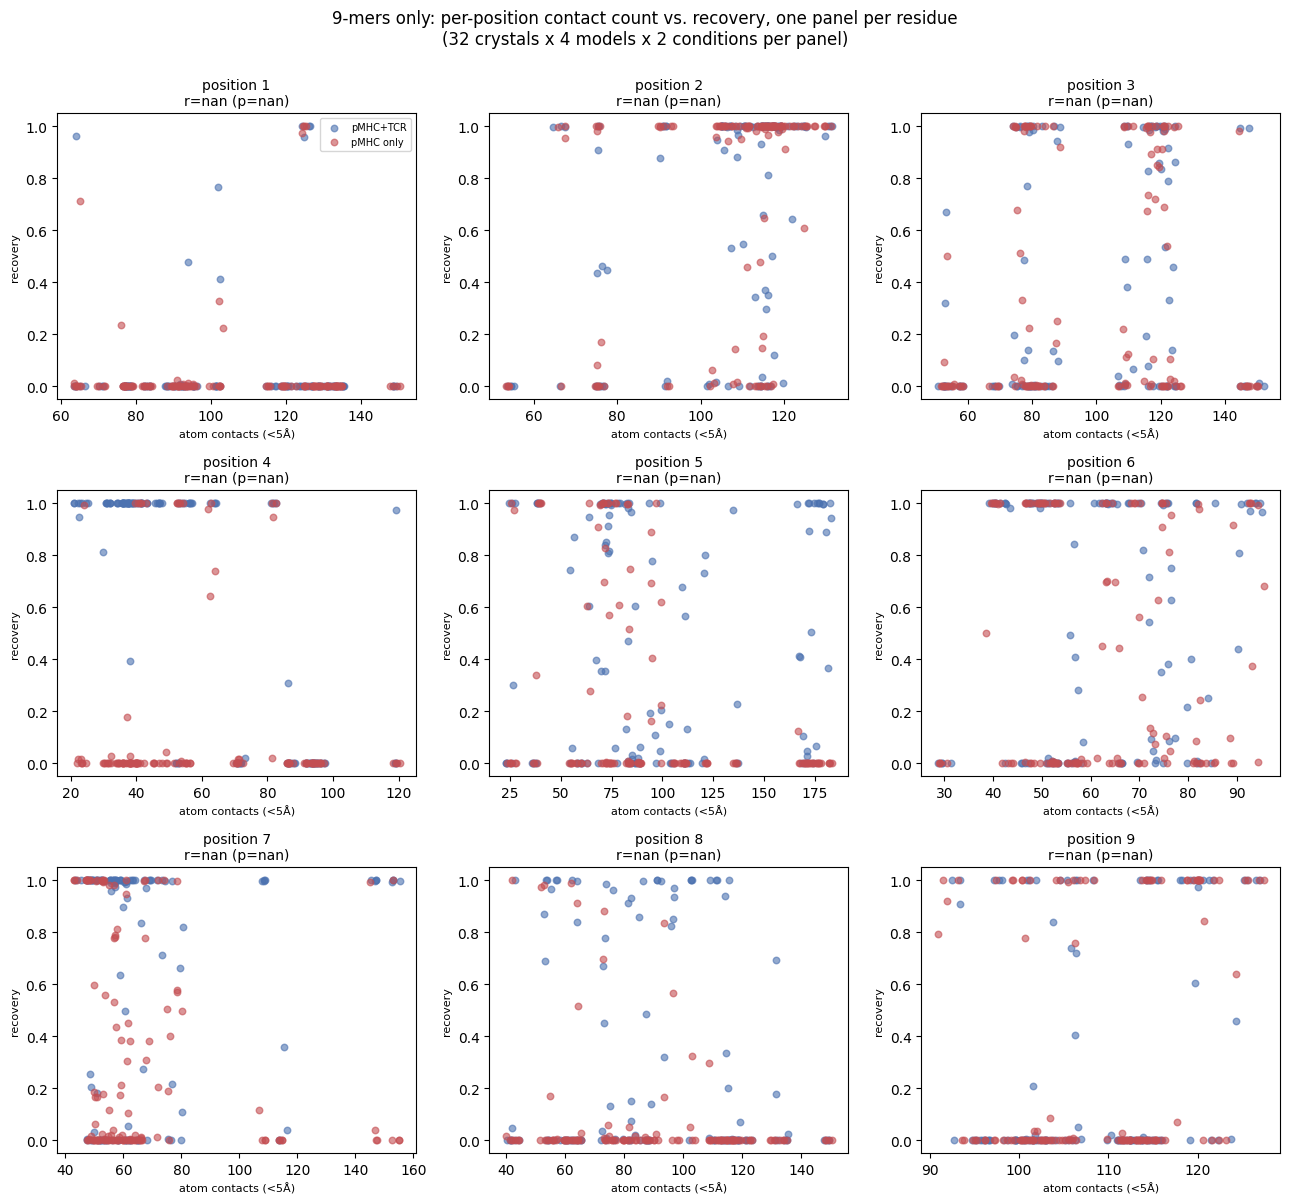

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_9mer_contacts_vs_recovery_by_position.png


In [13]:
NINE_MERS = [pdb for pdb in STRUCTS if len(natives[pdb]) == 9]
print(f"{len(NINE_MERS)} nine-mer crystals: {NINE_MERS}")

def parse_atoms_by_residue(path, chains):
    coords = {c: [] for c in chains}
    resnum = {c: [] for c in chains}
    with open(path) as f:
        for line in f:
            if line.startswith("ATOM") and line[21] in chains:
                c = line[21]
                coords[c].append((float(line[30:38]), float(line[38:46]), float(line[46:54])))
                resnum[c].append(line[22:27])
    return ({c: np.array(coords[c]).reshape(-1, 3) for c in chains},
            {c: np.array(resnum[c]) for c in chains})

def per_residue_contacts(pep, pep_res, partner, cutoff=5.0):
    d = np.linalg.norm(pep[:, None, :] - partner[None, :, :], axis=2)
    within = d < cutoff
    out = {}
    for local_pos, resnum in enumerate(pd.unique(pep_res), start=1):
        mask = pep_res == resnum
        out[local_pos] = int(within[mask].sum())
    return out

nine_mer_contacts = {}
for pdb in NINE_MERS:
    path = ROOT / f"outputs/panel_prep/{pdb}/pdbs/full/{pdb}.pdb"
    coords, resnum = parse_atoms_by_residue(path, ["A", "C", "D", "E"])
    pep, pep_res = coords["C"], resnum["C"]
    tcr = np.vstack([coords["D"], coords["E"]])
    tcr_n = per_residue_contacts(pep, pep_res, tcr)
    mhc_n = per_residue_contacts(pep, pep_res, coords["A"])
    nine_mer_contacts[pdb] = {pos: tcr_n[pos] + mhc_n[pos] for pos in tcr_n}

COND_COLOR = {"full": "#4C72B0", "mhconly": "#C44E52"}
fig, axes = plt.subplots(3, 3, figsize=(13, 12))
rng9 = np.random.RandomState(0)
for pos in range(1, 10):
    ax = axes[(pos - 1) // 3, (pos - 1) % 3]
    xs_all, ys_all = [], []
    for cond in CONDITIONS:
        xs, ys = [], []
        for pdb in NINE_MERS:
            n_contacts = nine_mer_contacts[pdb][pos]
            for j, model in enumerate(MODELS):
                xs.append(n_contacts + rng9.uniform(-1.5, 1.5))
                ys.append(recovery_mat[(pdb, cond)][pos - 1, j])
        ax.scatter(xs, ys, s=22, alpha=0.6, color=COND_COLOR[cond], label=COND_LABEL[cond])
        xs_all.extend(xs); ys_all.extend(ys)
    r, p = pearsonr(xs_all, ys_all)
    ax.set_title(f"position {pos}\nr={r:.2f} (p={p:.2f})", fontsize=10)
    ax.set_xlabel("atom contacts (<5Å)", fontsize=8)
    ax.set_ylabel("recovery", fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    if pos == 1:
        ax.legend(fontsize=7)
fig.suptitle("9-mers only: per-position contact count vs. recovery, one panel per residue\n"
             f"({len(NINE_MERS)} crystals x 4 models x 2 conditions per panel)", y=1.0)
fig.tight_layout()
out = FIG_DIR / "fig_panel3_9mer_contacts_vs_recovery_by_position.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 9. Recovery vs. resolution, and number of unique designs vs. resolution, full panel

Left: resolution vs. recovery. Right: resolution vs. number of unique designs -- does crystal quality
predict how many distinct designs come out, independent of recovery? Both panels share resolution as
the x-axis for a direct comparison.

dropping 5 structure(s) without all four models: 1LP9, 2J8U, 2JCC, 2UWE, 4P23


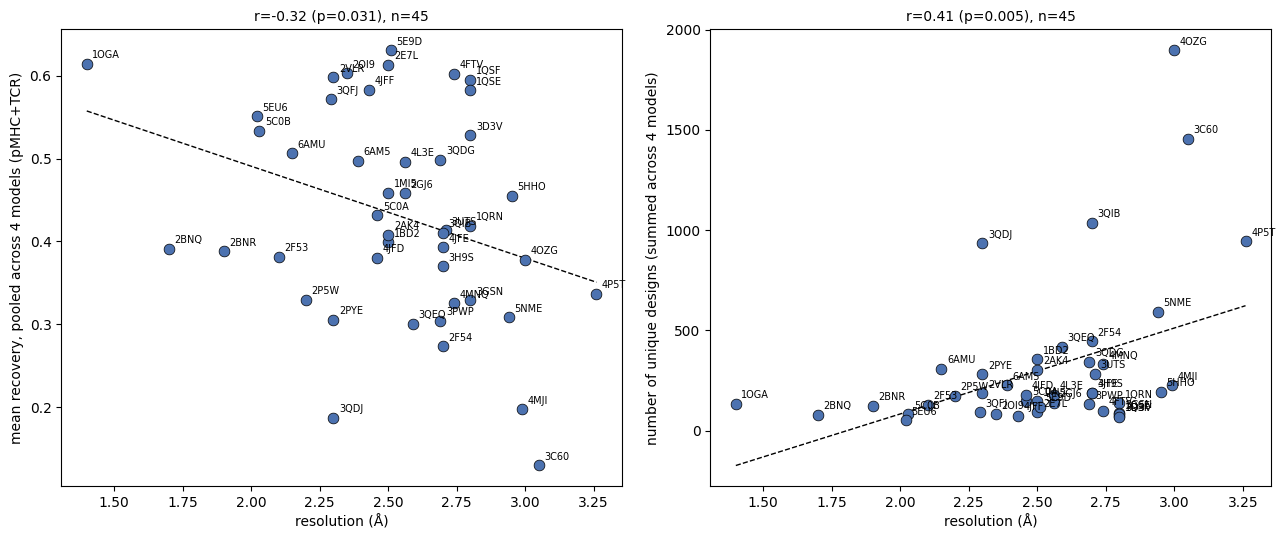

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_vs_resolution_and_unique.png
 pdb  resolution_A  unique  mean_recovery
2P5W          2.20     174       0.329669
1QSF          2.80      72       0.594788
1QRN          2.80     137       0.418806
2BNR          1.90     123       0.387918
2GJ6          2.56     140       0.457813
2F53          2.10     129       0.381232
2F54          2.70     446       0.273421
3QDG          2.69     343       0.498638
3QEQ          2.59     417       0.300926
3QFJ          2.29      92       0.571236
3GSN          2.80      86       0.329177
1OGA          1.40     134       0.613977
3UTS          2.71     284       0.413214
5C0A          2.46     148       0.431548
5C0B          2.03      82       0.533581
5HHO          2.95     195       0.455267
5EU6          2.02      52       0.550904
2VLR          2.30     186       0.598068
4MJI          2.99     226       0.197529
5NME          2.94     592       0.308226
1B

In [14]:
master = pd.read_csv(ROOT / "outputs/analysis/panel_dataset_master_table.csv")
div_data = pd.read_csv(ROOT / "outputs/analysis/diversity_drivers_data.csv")

# a structure is only comparable here if all four models produced designs for it -- summing
# unique counts over three models for the few cells LigandMPNN never filled would understate
# their diversity, so those structures are dropped from both panels rather than half-counted
full_div = div_data[div_data.condition == "full"]
complete = set(full_div.groupby("pdb")["model"].nunique().pipe(lambda s: s[s == len(MODELS)]).index)
dropped = [p for p in STRUCTS if p not in complete]
if dropped:
    print(f"dropping {len(dropped)} structure(s) without all four models: {', '.join(dropped)}")

panel_recovery = pd.DataFrame({"pdb": STRUCTS, "mean_recovery": np.nanmean(mat_full, axis=0)})
panel_unique = full_div.groupby("pdb")["unique"].sum().reset_index()
panel_df = panel_recovery.merge(panel_unique, on="pdb").merge(
    master[["pdb", "resolution_A"]], on="pdb")
panel_df = panel_df[panel_df["pdb"].isin(complete)].reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
panel_specs = [(axes[0], "mean_recovery", "mean recovery, pooled across 4 models (pMHC+TCR)"),
              (axes[1], "unique", "number of unique designs (summed across 4 models)")]
for ax, ycol, ylabel in panel_specs:
    ax.scatter(panel_df["resolution_A"], panel_df[ycol], c="#4C72B0", s=60, edgecolor="black",
               linewidth=0.5, zorder=3)
    for _, row in panel_df.iterrows():
        ax.annotate(row["pdb"], (row["resolution_A"], row[ycol]), fontsize=7,
                    xytext=(4, 4), textcoords="offset points")
    m, b = np.polyfit(panel_df["resolution_A"], panel_df[ycol], 1)
    xs_line = np.linspace(panel_df["resolution_A"].min(), panel_df["resolution_A"].max(), 50)
    ax.plot(xs_line, m * xs_line + b, color="black", linestyle="--", linewidth=1)
    r, p = pearsonr(panel_df["resolution_A"], panel_df[ycol])
    ax.set_xlabel("resolution (Å)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"r={r:.2f} (p={p:.3f}), n={len(panel_df)}", fontsize=10)
fig.tight_layout()
out = FIG_DIR / "fig_panel3_recovery_vs_resolution_and_unique.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
print(panel_df[["pdb", "resolution_A", "unique", "mean_recovery"]].to_string(index=False))

## 10. Same, split by model (2 rows x 4 columns, pMHC+TCR only)

Section 9 pooled all 4 models together per structure -- does the resolution/diversity relationship
hold for every model individually, or is it driven by one or two of them? Top row: the two ProteinMPNN
variants (each taking 2 columns -- resolution vs. recovery, then resolution vs. number of unique
designs). Bottom row: ESM-IF1 and LigandMPNN, same layout. pMHC+TCR only.

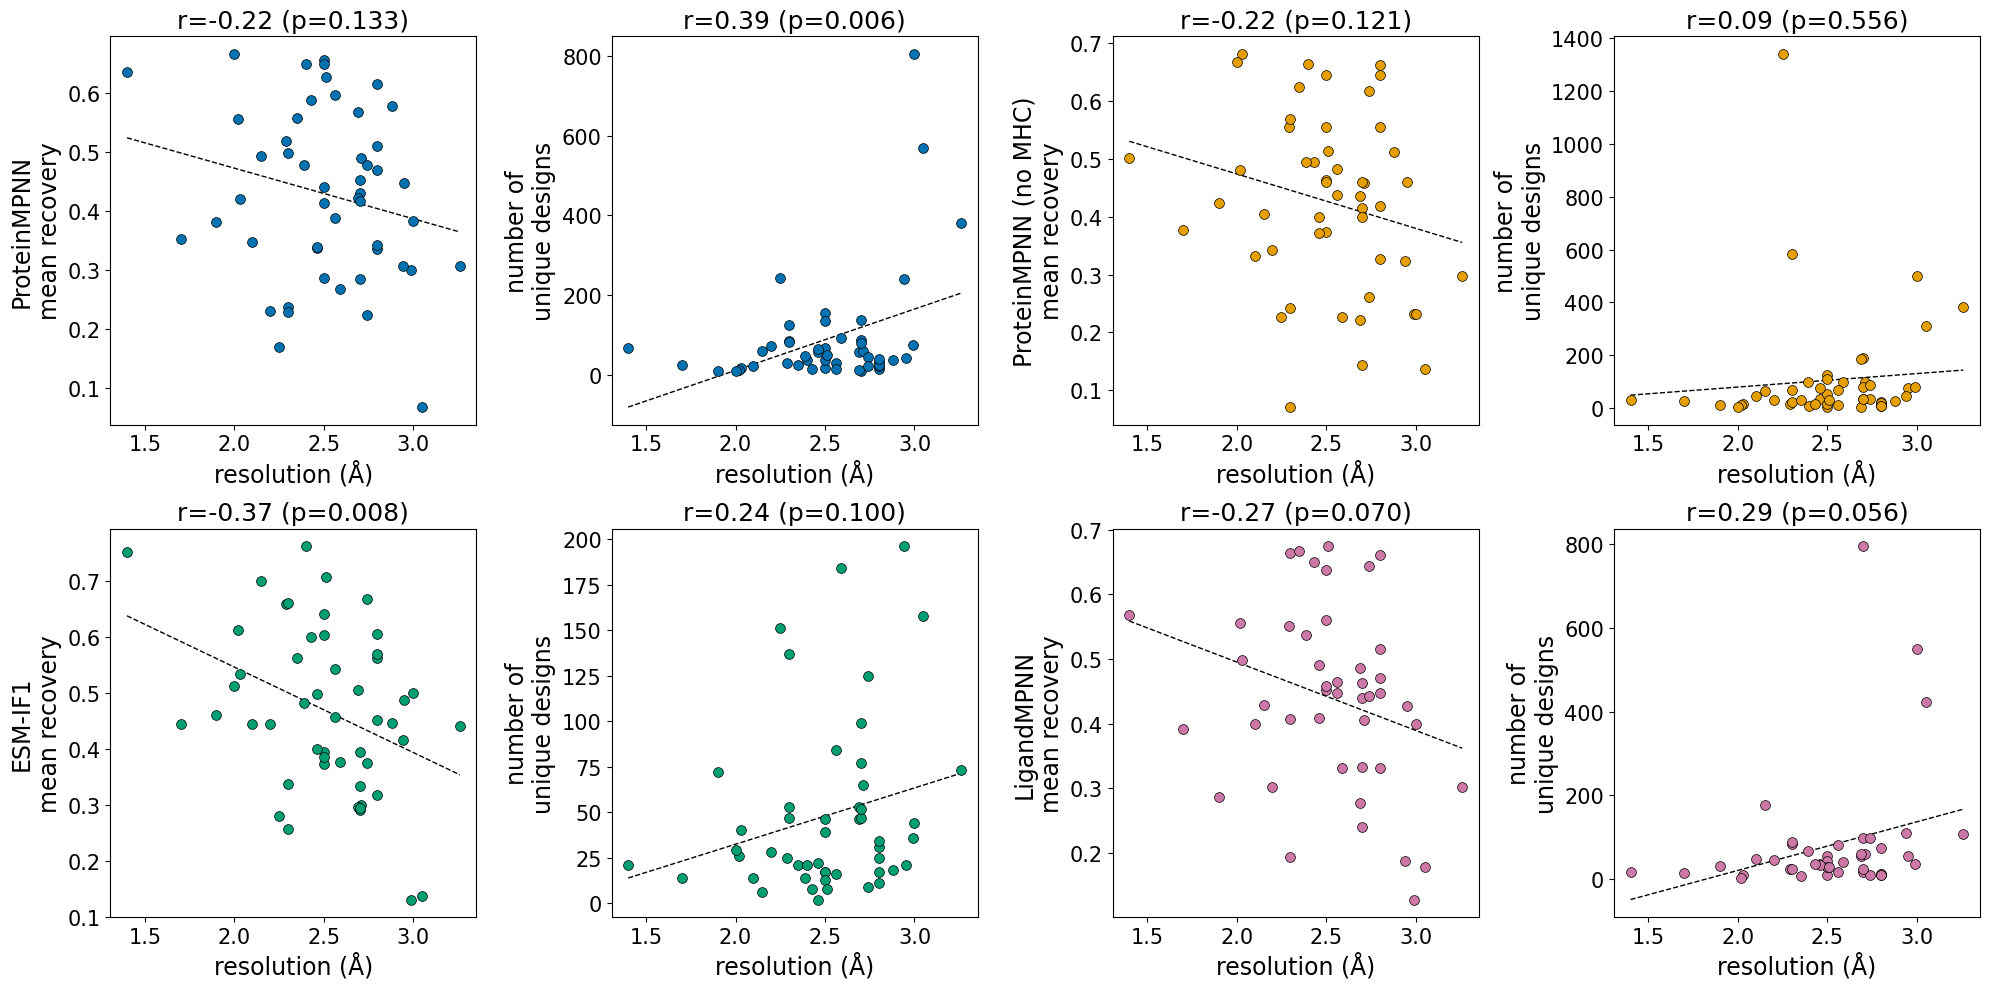

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_recovery_vs_resolution_and_unique_by_model.png


In [15]:
MODEL_ROWS = [["vanilla", "noMHC"], ["ESM-IF1", "LigandMPNN"]]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for row, model_pair in enumerate(MODEL_ROWS):
    for pair_idx, model in enumerate(model_pair):
        i = MODELS.index(model)
        model_recovery = pd.DataFrame({"pdb": STRUCTS, "mean_recovery": mat_full[i, :]})
        model_unique = (div_data[(div_data.condition == "full") & (div_data.model == model)]
                        [["pdb", "unique"]])
        model_df = model_recovery.merge(model_unique, on="pdb").merge(
            master[["pdb", "resolution_A"]], on="pdb")
        for j, (ycol, ylabel) in enumerate([("mean_recovery", "mean recovery"),
                                            ("unique", "number of\nunique designs")]):
            col = pair_idx * 2 + j
            ax = axes[row, col]
            ax.scatter(model_df["resolution_A"], model_df[ycol], c=MODEL_COLOR[model], s=50,
                       edgecolor="black", linewidth=0.5, zorder=3)
            m, b = np.polyfit(model_df["resolution_A"], model_df[ycol], 1)
            xs_line = np.linspace(model_df["resolution_A"].min(), model_df["resolution_A"].max(), 50)
            ax.plot(xs_line, m * xs_line + b, color="black", linestyle="--", linewidth=1)
            r, p = pearsonr(model_df["resolution_A"], model_df[ycol])
            ax.set_xlabel("resolution (Å)", fontsize=17)
            ax.tick_params(labelsize=15)
            if j == 0:
                ax.set_ylabel(f"{MODEL_LABEL[model]}\n{ylabel}", fontsize=17)
            else:
                ax.set_ylabel(ylabel, fontsize=17)
            ax.set_title(f"r={r:.2f} (p={p:.3f})", fontsize=18)
fig.tight_layout()
out = FIG_DIR / "fig_panel3_recovery_vs_resolution_and_unique_by_model.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")

## 10. Does the anchor result depend on the panel's redundancy?

Fifty structures are not fifty independent observations. The panel holds 33 distinct peptides and 26
distinct CDR3$\beta$ sequences: SLLMWITQC is solved in five crystals, ELAGIGILTV and ALWGFFPVL in four
each, and several receptors (A6, 1G4, DMF5) recur. A pooled statistic therefore weights an epitope by
how often it happened to be crystallised, which double-counts whatever makes that particular index
peptide easy or hard to recover.

The sets below get progressively stricter: human MHC class I only, then one structure per TCR family
(CDR3$\beta$ clustered so clonotypes differing by one or two substitutions collapse together), then one
per peptide, then restricted to HLA-A*02:01. Each group's representative is its best-resolution
member, chosen independently of any score. Built by `py/dedup_test_sets.py`.

In [16]:
import sys
sys.path.insert(0, str(ROOT / "py"))
from dedup_test_sets import build_sets

master = pd.read_csv(ROOT / "outputs/analysis/panel_dataset_master_table.csv")
perpos = pd.read_parquet(ROOT / "outputs/design_corpus_perpos.parquet")
SETS = build_sets(master)

rows = []
for name, pdbs in SETS.items():
    s = perpos[(perpos.arm == "full") & (perpos.pdb.isin(pdbs))]
    interior = s.loc[s.region == "interior", "recovery"]
    rec = dict(set=name, n_struct=len(pdbs),
               n_peptide=master[master.pdb.isin(pdbs)].peptide.nunique(),
               interior=interior.mean())
    for reg in ["P2", "POmega"]:
        v = s.loc[s.region == reg, "recovery"]
        rec[reg], rec[f"p_{reg}"] = v.mean(), mannwhitneyu(v, interior)[1]
    rows.append(rec)
dedup = pd.DataFrame(rows)
print(dedup.round(4).to_string(index=False))

                           set  n_struct  n_peptide  interior     P2   p_P2  POmega  p_POmega
                           all        50         33    0.4860 0.6414 0.0000  0.2534       0.0
                        humanI        43         29    0.5101 0.6708 0.0000  0.2131       0.0
              humanI+uniqueTCR        17         15    0.5495 0.6358 0.1643  0.2223       0.0
humanI+uniqueTCR+uniquePeptide        33         29    0.5109 0.6331 0.0053  0.1895       0.0
    A2+uniqueTCR+uniquePeptide        30         26    0.5231 0.6440 0.0095  0.1748       0.0


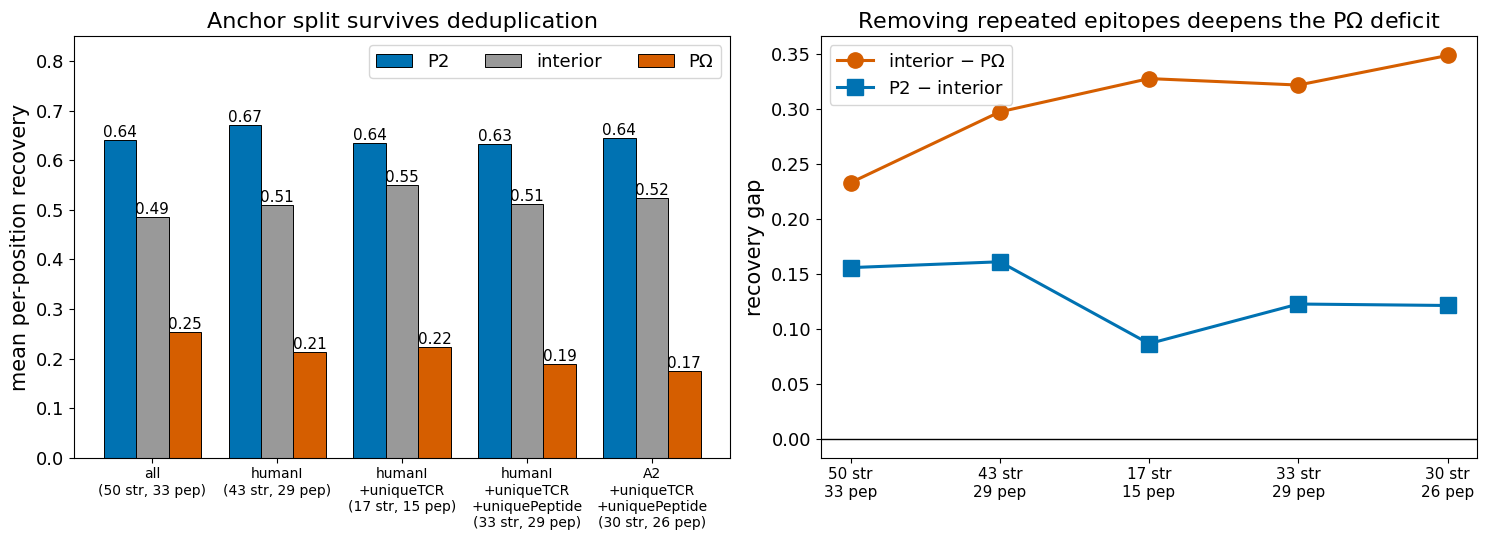

wrote /home/ubuntu/if-mhc/figures/fig_panel3_recovery_presentation/fig_panel3_anchor_dedup_sets.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
labels = [n.replace("+", "\n+") for n in dedup.set]
x = np.arange(len(dedup)); w = 0.26

for k, (col, c, lab) in enumerate([("P2", "#0072B2", "P2"),
                                   ("interior", "#999999", "interior"),
                                   ("POmega", "#D55E00", "P$\\Omega$")]):
    b = axes[0].bar(x + (k - 1) * w, dedup[col], w, color=c, label=lab,
                    edgecolor="black", linewidth=0.7)
    for r_ in b:
        axes[0].annotate(f"{r_.get_height():.2f}",
                         (r_.get_x() + r_.get_width() / 2, r_.get_height()),
                         ha="center", va="bottom", fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{l}\n({n} str, {p} pep)" for l, n, p in
                         zip(labels, dedup.n_struct, dedup.n_peptide)], fontsize=10)
axes[0].set_ylabel("mean per-position recovery", fontsize=15)
axes[0].set_ylim(0, 0.85)
axes[0].set_title("Anchor split survives deduplication", fontsize=16)
axes[0].legend(fontsize=13, ncol=3)
axes[0].tick_params(axis="y", labelsize=13)

# the P-Omega deficit as a gap, which is what actually deepens
axes[1].plot(x, dedup.interior - dedup.POmega, "o-", color="#D55E00", markersize=11,
             linewidth=2.2, label="interior $-$ P$\\Omega$")
axes[1].plot(x, dedup.P2 - dedup.interior, "s-", color="#0072B2", markersize=11,
             linewidth=2.2, label="P2 $-$ interior")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{n} str\n{p} pep" for n, p in zip(dedup.n_struct, dedup.n_peptide)],
                        fontsize=11)
axes[1].set_ylabel("recovery gap", fontsize=15)
axes[1].set_title("Removing repeated epitopes deepens the P$\\Omega$ deficit",
                  fontsize=16)
axes[1].legend(fontsize=13)
axes[1].tick_params(axis="y", labelsize=13)
fig.tight_layout()
out = FIG_DIR / "fig_panel3_anchor_dedup_sets.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"wrote {out}")
dedup.to_csv(ROOT / "outputs/analysis/dedup_test_sets_anchor.csv", index=False)